# DDXPlus Hybrid V1: Online MLP Feedback For Sequential Workup

This notebook keeps the single-agent LLM evidence-acquisition policy from notebook `08`, but runs the selected partial-evidence MLP after each ledger update. The MLP acts as a belief monitor for stopping and final-head adjudication; it does not reveal hidden evidence and it does not choose evidence directly in v1.

In [9]:
# Optional secure env bootstrap for live API runs.
# This notebook is non-interactive by default; paste keys into env vars before running live.

import os

os.environ.setdefault("LLM_BASE_URL", "https://api.openai.com/v1")
os.environ.setdefault("LLM_MODEL", "gpt-4.1-mini")
INTERACTIVE_API_KEY_BOOTSTRAP = True

if INTERACTIVE_API_KEY_BOOTSTRAP and not os.environ.get("LLM_API_KEY"):
    from getpass import getpass
    os.environ["LLM_API_KEY"] = getpass("Enter LLM_API_KEY: ")


In [10]:
from __future__ import annotations

import ast
import json
import math
import os
import random
import re
import subprocess
import sys
import time
import zipfile
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
from torch import nn
from IPython.display import display
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 20)

ROOT = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "scripts" / "download_ddxplus.py").exists()),
    Path.cwd(),
)
DATASET_ENV_VAR = "DDXPLUS_DATASET_DIR"
DEFAULT_DATASET_DIR = ROOT / "dataset"
LEGACY_DATASET_DIR = ROOT / ".data" / "ddxplus" / "22687585"
DATASET_DIR = (
    Path(os.environ[DATASET_ENV_VAR]).expanduser()
    if os.environ.get(DATASET_ENV_VAR)
    else DEFAULT_DATASET_DIR
    if DEFAULT_DATASET_DIR.exists()
    else LEGACY_DATASET_DIR
    if LEGACY_DATASET_DIR.exists()
    else DEFAULT_DATASET_DIR
)
AUTO_DOWNLOAD_IF_MISSING = True

# Main run controls. Edit these directly in the notebook.
# True = call the configured LLM API. False = do not make live API calls.
RUN_LIVE_API = True
ALLOW_DRY_RUN_BENCHMARK = False  # Set True only for cheap smoke tests without API calls.
RUN_REPLAY_DIAGNOSTICS = False
RESUME_IF_AVAILABLE = True

EVIDENCE_COST_LAMBDAS = [0.10, 0.22, 0.35]
MAX_REQUEST_CAP = 24
SEQUENTIAL_SAMPLE_PER_CLASS = 1
SEQUENTIAL_MAX_CASES = 24  # Use 24 for the first live pilot; use None for the full 49-case balanced slice.
RANDOM_SEED = 2919
SPLIT_NAME = "test"
TEMPERATURE = 0.0
TOP_P = 1.0

SHORTLIST_SIZE = 10
SHORTLIST_STATS_SOURCE = "validate"
SHORTLIST_STATS_MAX_ROWS = 30000
USE_ONE_SHOT_PRIOR = True
ONE_SHOT_PRIOR_TOP_K = 5
PRIOR_BLEND_WEIGHT = 0.55
STATE_TOP_K = 5
STATE_SOFTMAX_TEMPERATURE = 0.33
STOP_CONFIDENCE_THRESHOLD = 0.60
LOW_VALUE_SHORTLIST_THRESHOLD = 0.12
GENERIC_RATE_PENALTY_THRESHOLD = 0.50

DRIFT_GUARD_TOP_K = 4
DRIFT_GUARD_MARGIN_THRESHOLD = 0.08
DRIFT_GUARD_CONFIDENCE_THRESHOLD = 0.72
FORCE_REQUEST_MARGIN_THRESHOLD = 0.07
FORCE_REQUEST_SCORE_THRESHOLD = 0.14
FORCE_STOP_MAX_SHORTLIST_SCORE = 0.10
MIN_REQUESTS_BEFORE_COST_STOP = 1
COST_FORCE_REQUEST_MARGIN = 0.05
COST_FORCE_STOP_UTILITY = -0.015

REPLAY_SOURCE_RUN_NAME = "single_agent_improved_live_test_1perclass_4budgets_ledger_shortlist_budget_sweep_v1"
RUN_VERSION = os.environ.get("HYBRID_RUN_VERSION", "hybrid_mlp_feedback_v1")

LLM_BASE_URL = os.environ.get("LLM_BASE_URL", "https://api.openai.com/v1")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "")
LLM_MODEL = os.environ.get("LLM_MODEL", "gpt-4.1-mini")
USE_JSON_MODE = False

INPUT_COST_PER_1K_TOKENS = None
OUTPUT_COST_PER_1K_TOKENS = None

run_prefix = "live" if RUN_LIVE_API else "dryrun"
RUN_NAME = (
    f"hybrid_mlp_feedback_{run_prefix}_{SPLIT_NAME}_"
    f"{SEQUENTIAL_SAMPLE_PER_CLASS}perclass_cap{MAX_REQUEST_CAP}_"
    f"{len(EVIDENCE_COST_LAMBDAS)}lambdas_{RUN_VERSION}"
)
ARTIFACT_ROOT = ROOT / "artifacts" / "sequential_hybrid_mlp_feedback" / RUN_NAME
CACHE_DIR = ARTIFACT_ROOT / "cache"
FIGURE_DIR = ARTIFACT_ROOT / "figures"
for directory in [ARTIFACT_ROOT, CACHE_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root      :", ROOT)
print("Dataset dir       :", DATASET_DIR)
print("Run live API      :", RUN_LIVE_API)
print("Evidence lambdas  :", EVIDENCE_COST_LAMBDAS)
print("Max request cap   :", MAX_REQUEST_CAP)
print("Sample per class  :", SEQUENTIAL_SAMPLE_PER_CLASS)
print("Max benchmark rows:", SEQUENTIAL_MAX_CASES)
print("Artifact root     :", ARTIFACT_ROOT)


HYBRID_MIN_REQUESTS_BEFORE_MLP_STOP = 1
HYBRID_CONFIDENCE_THRESHOLD = 0.58
HYBRID_MARGIN_THRESHOLD = 0.16
HYBRID_ENTROPY_THRESHOLD = 0.62
HYBRID_STABILITY_TURNS = 1
HYBRID_FINAL_CONFIDENCE_THRESHOLD = 0.55
HYBRID_FINAL_MARGIN_THRESHOLD = 0.12
HYBRID_DISAGREEMENT_CONTINUE_BONUS = 0.18
HYBRID_UNCERTAINTY_WEIGHT = 0.48
HYBRID_BASE_VALUE_WEIGHT = 0.52

print("Hybrid run name  :", RUN_NAME)
print("Hybrid artifact  :", ARTIFACT_ROOT)
print("Hybrid dry-run ok:", ALLOW_DRY_RUN_BENCHMARK)


Project root      : /Users/bilalawan/claw/assignments/baseline_model
Dataset dir       : /Users/bilalawan/claw/assignments/baseline_model/dataset
Run live API      : True
Evidence lambdas  : [0.1, 0.22, 0.35]
Max request cap   : 24
Sample per class  : 1
Max benchmark rows: 24
Artifact root     : /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_hybrid_mlp_feedback/hybrid_mlp_feedback_live_test_1perclass_cap24_3lambdas_hybrid_mlp_feedback_v1
Hybrid run name  : hybrid_mlp_feedback_live_test_1perclass_cap24_3lambdas_hybrid_mlp_feedback_v1
Hybrid artifact  : /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_hybrid_mlp_feedback/hybrid_mlp_feedback_live_test_1perclass_cap24_3lambdas_hybrid_mlp_feedback_v1
Hybrid dry-run ok: False



## Dataset And Artifact Helpers

The improved notebook keeps the same DDXPlus file-validation and split-loading conventions as the rest of the project so that:

- `case_id` remains stable
- one-shot predictions can be merged cleanly as priors
- sequential budget sweeps can be compared later without ad-hoc reformatting


In [11]:

REQUIRED_FILES = [
    "release_evidences.json",
    "release_conditions.json",
    "release_train_patients.zip",
    "release_validate_patients.zip",
    "release_test_patients.zip",
]

SPLIT_TO_FILENAME = {
    "train": "release_train_patients.zip",
    "validate": "release_validate_patients.zip",
    "test": "release_test_patients.zip",
}


def ensure_dataset_present(dataset_dir: Path, auto_download: bool = True) -> dict[str, Path]:
    dataset_dir.mkdir(parents=True, exist_ok=True)
    paths = {name: dataset_dir / name for name in REQUIRED_FILES}
    missing = [name for name, path in paths.items() if not path.exists()]
    if missing and auto_download:
        command = [sys.executable, str(ROOT / "scripts" / "download_ddxplus.py"), "--output-dir", str(dataset_dir)]
        subprocess.run(command, check=True)
        missing = [name for name, path in paths.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing DDXPlus files: {missing}")
    return paths


def load_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_patient_split(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as archive:
        members = [name for name in archive.namelist() if not name.endswith("/")]
        file_name = next((name for name in members if name.endswith(".csv")), None)
        if file_name is None:
            if not members:
                raise ValueError(f"Archive is empty: {zip_path}")
            file_name = members[0]
        with archive.open(file_name) as handle:
            return pd.read_csv(handle)


def attach_split_metadata(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
    enriched = frame.copy()
    enriched["split"] = split_name
    enriched["source_row_index"] = np.arange(len(enriched), dtype=int)
    enriched["case_id"] = enriched["source_row_index"].map(lambda idx: f"{split_name}:{idx}")
    return enriched


def sample_fixed_cases_per_pathology(frame: pd.DataFrame, label_col: str, per_class: int, seed: int) -> pd.DataFrame:
    sampled_parts = []
    for pathology, group in frame.groupby(label_col, sort=True):
        take_n = min(per_class, len(group))
        sampled_parts.append(group.sample(n=take_n, random_state=seed))
    sampled = pd.concat(sampled_parts, ignore_index=False)
    sampled = sampled.sort_values([label_col, "source_row_index"]).reset_index(drop=True)
    return sampled


def append_jsonl(path: Path, payload: dict[str, Any]) -> None:
    with path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(payload, ensure_ascii=True) + "\n")


def upsert_prediction_row(path: Path, row: dict[str, Any]) -> None:
    frame = pd.DataFrame([row])
    if path.exists():
        existing = pd.read_csv(path)
        existing = existing[existing["case_id"] != row["case_id"]]
        frame = pd.concat([existing, frame], ignore_index=True)
    frame.to_csv(path, index=False)


def safe_parse_list(raw: Any) -> list[Any]:
    if isinstance(raw, list):
        return raw
    if raw is None:
        return []
    if isinstance(raw, float) and np.isnan(raw):
        return []
    if isinstance(raw, str):
        stripped = raw.strip()
        if not stripped:
            return []
        try:
            return json.loads(stripped)
        except Exception:
            return ast.literal_eval(stripped)
    return list(raw)

## Deterministic Evidence Ledger And Episode State Manager

The ledger still records the visible clinical state, but the episode now also stores enough diagnosis-state metadata to support anchored revision instead of free drift.

In [12]:
from __future__ import annotations
def parse_evidence_token(token: str) -> tuple[str, str | None]:
    if "_@_" not in token:
        return token, None
    root_id, value = token.split("_@_", 1)
    return root_id, value


@dataclass
class LedgerEntry:
    turn_index: int
    root_evidence_id: str
    question_en: str
    source: str
    status: str
    values: list[str] = field(default_factory=list)
    decoded_values: list[str] = field(default_factory=list)
    summary: str = ""


@dataclass
class DiagnosisSnapshot:
    turn_index: int
    predicted_pathology: str
    ranked_differential: list[str]
    confidence: float
    decision: str
    requested_evidence_id: str | None
    brief_reasoning: str
    stop_signal_level: str
    top_shortlist_score: float
    deterministic_top_pathology: str | None = None
    deterministic_margin: float = 0.0
    policy_flags: list[str] = field(default_factory=list)


@dataclass
class LedgerEpisodeState:
    case_id: str
    split_name: str
    source_row_index: int
    age: int
    sex: str
    pathology: str
    initial_evidence: str
    evidence_by_root: dict[str, list[str]]
    revealed_roots: set[str]
    evidence_ledger: list[LedgerEntry]
    request_history: list[dict[str, Any]]
    diagnosis_history: list[DiagnosisSnapshot]
    shortlist_history: list[list[dict[str, Any]]]
    prior_differential: list[tuple[str, float]]


class DeterministicEvidenceLedger:
    def __init__(self, evidence_metadata: dict[str, dict[str, Any]]):
        self.evidence_metadata = evidence_metadata
        self.root_ids = list(evidence_metadata.keys())
        self.question_text = {
            root_id: meta.get("question_en", root_id) for root_id, meta in evidence_metadata.items()
        }
        self.data_types = {
            root_id: meta.get("data_type", "B") for root_id, meta in evidence_metadata.items()
        }
        self.parent_question = {
            root_id: str(meta.get("code_question", root_id) or root_id)
            for root_id, meta in evidence_metadata.items()
        }

    def tokens_to_values(self, root_id: str, tokens: list[str]) -> list[str]:
        if self.data_types[root_id] == "B":
            return ["present"] if tokens else []
        return [value for _, value in map(parse_evidence_token, tokens) if value is not None]

    def decode_value(self, root_id: str, value: str) -> str:
        if value == "present":
            return "yes"
        value_meaning = self.evidence_metadata[root_id].get("value_meaning", {})
        if isinstance(value_meaning, dict):
            entry = value_meaning.get(str(value))
            if isinstance(entry, dict):
                human = entry.get("en") or entry.get("fr")
                if human:
                    return str(human)
            elif entry:
                return str(entry)
        return str(value)

    def decode_values(self, root_id: str, values: list[str]) -> list[str]:
        return [self.decode_value(root_id, value) for value in values]

    def summarize_observation(self, root_id: str, values: list[str], status: str) -> str:
        question = self.question_text[root_id]
        if status == "absent":
            return f"{question} -> no"
        if self.data_types[root_id] == "B":
            return f"{question} -> yes"
        decoded_values = self.decode_values(root_id, values)
        return f"{question} -> {', '.join(decoded_values) if decoded_values else 'observed'}"

    def _make_entry(self, turn_index: int, root_id: str, source: str, status: str, values: list[str]) -> LedgerEntry:
        decoded_values = self.decode_values(root_id, values)
        return LedgerEntry(
            turn_index=turn_index,
            root_evidence_id=root_id,
            question_en=self.question_text[root_id],
            source=source,
            status=status,
            values=list(values),
            decoded_values=decoded_values,
            summary=self.summarize_observation(root_id, values, status),
        )

    def from_row(
        self,
        row: dict[str, Any],
        split_name: str,
        prior_differential: list[tuple[str, float]] | None = None,
    ) -> LedgerEpisodeState:
        evidences_list = [str(token) for token in safe_parse_list(row["EVIDENCES"])]
        initial_evidence = str(row["INITIAL_EVIDENCE"])
        initial_root, _ = parse_evidence_token(initial_evidence)
        evidence_by_root: dict[str, list[str]] = {}
        for token in evidences_list:
            root_id, _ = parse_evidence_token(token)
            evidence_by_root.setdefault(root_id, []).append(token)
        initial_values = self.tokens_to_values(initial_root, evidence_by_root.get(initial_root, [initial_evidence]))
        initial_entry = self._make_entry(0, initial_root, "initial_evidence", "present", initial_values)
        return LedgerEpisodeState(
            case_id=str(row["case_id"]),
            split_name=split_name,
            source_row_index=int(row["source_row_index"]),
            age=int(row["AGE"]),
            sex=str(row["SEX"]),
            pathology=str(row["PATHOLOGY"]),
            initial_evidence=initial_evidence,
            evidence_by_root=evidence_by_root,
            revealed_roots={initial_root},
            evidence_ledger=[initial_entry],
            request_history=[],
            diagnosis_history=[],
            shortlist_history=[],
            prior_differential=list(prior_differential or []),
        )

    def root_present_or_implied_present(self, root_id: str, episode: LedgerEpisodeState) -> bool:
        if root_id in episode.revealed_roots and bool(episode.evidence_by_root.get(root_id, [])):
            return True
        for revealed_root in episode.revealed_roots:
            if (
                self.parent_question.get(revealed_root, revealed_root) == root_id
                and bool(episode.evidence_by_root.get(revealed_root, []))
            ):
                return True
        return False

    def parent_is_satisfied(self, root_id: str, episode: LedgerEpisodeState) -> bool:
        parent_root = self.parent_question.get(root_id, root_id)
        if parent_root == root_id:
            return True
        return self.root_present_or_implied_present(parent_root, episode)

    def legal_actions(self, episode: LedgerEpisodeState) -> list[dict[str, Any]]:
        available = []
        for root_id in self.root_ids:
            if root_id in episode.revealed_roots:
                continue
            if not self.parent_is_satisfied(root_id, episode):
                continue
            parent_root = self.parent_question.get(root_id, root_id)
            available.append(
                {
                    "root_evidence_id": root_id,
                    "question_en": self.question_text[root_id],
                    "parent_root_id": parent_root,
                    "is_child": bool(parent_root != root_id),
                }
            )
        return available

    def reveal(self, episode: LedgerEpisodeState, root_evidence_id: str, turn_index: int) -> dict[str, Any]:
        episode.revealed_roots.add(root_evidence_id)
        revealed_tokens = list(episode.evidence_by_root.get(root_evidence_id, []))
        values = self.tokens_to_values(root_evidence_id, revealed_tokens)
        status = "present" if revealed_tokens else "absent"
        entry = self._make_entry(turn_index, root_evidence_id, "request", status, values)
        episode.evidence_ledger.append(entry)
        episode.request_history.append(
            {
                "turn_index": turn_index,
                "root_evidence_id": root_evidence_id,
                "status": status,
                "values": list(values),
                "decoded_values": list(entry.decoded_values),
                "summary": entry.summary,
            }
        )
        return {
            "root_evidence_id": root_evidence_id,
            "question_en": self.question_text[root_evidence_id],
            "status": status,
            "revealed_tokens": revealed_tokens,
            "revealed_values": list(values),
            "revealed_value_labels": list(entry.decoded_values),
            "summary": entry.summary,
        }

    def register_diagnosis(
        self,
        episode: LedgerEpisodeState,
        turn_index: int,
        normalized_response: dict[str, Any],
        shortlist_snapshot: list[dict[str, Any]],
        stop_signal: dict[str, Any],
        state_summary: DiagnosticStateSummary,
        policy_flags: list[str] | None = None,
    ) -> None:
        top_score = float(shortlist_snapshot[0]["score"]) if shortlist_snapshot else 0.0
        episode.diagnosis_history.append(
            DiagnosisSnapshot(
                turn_index=turn_index,
                predicted_pathology=normalized_response["predicted_pathology"],
                ranked_differential=list(normalized_response["ranked_differential"]),
                confidence=float(normalized_response["confidence"]),
                decision=str(normalized_response["decision"]),
                requested_evidence_id=normalized_response["requested_evidence_id"],
                brief_reasoning=str(normalized_response["brief_reasoning"]),
                stop_signal_level=str(stop_signal["level"]),
                top_shortlist_score=top_score,
                deterministic_top_pathology=(state_summary.top_candidates[0][0] if state_summary.top_candidates else None),
                deterministic_margin=float(state_summary.margin),
                policy_flags=list(policy_flags or []),
            )
        )
        episode.shortlist_history.append(list(shortlist_snapshot))

    def render_ledger(self, episode: LedgerEpisodeState) -> str:
        return "\n".join(
            f"- {entry.root_evidence_id}: {entry.summary} [source={entry.source}]"
            for entry in episode.evidence_ledger
        )

    def request_history_text(self, episode: LedgerEpisodeState) -> str:
        if not episode.request_history:
            return "- no additional requests yet"
        return "\n".join(
            f"- turn {item['turn_index']}: {item['summary']}"
            for item in episode.request_history
        )

    def diagnosis_history_text(self, episode: LedgerEpisodeState) -> str:
        if not episode.diagnosis_history:
            return "- no diagnosis snapshots yet"
        return "\n".join(
            (
                f"- turn {snap.turn_index}: pred={snap.predicted_pathology}, det_top={snap.deterministic_top_pathology}, "
                f"margin={snap.deterministic_margin:.2f}, decision={snap.decision}, confidence={snap.confidence:.2f}"
            )
            for snap in episode.diagnosis_history[-3:]
        )

    def visible_context(self, episode: LedgerEpisodeState) -> dict[str, Any]:
        return {
            "case_id": episode.case_id,
            "age": episode.age,
            "sex": episode.sex,
            "visible_ledger": self.render_ledger(episode),
            "request_history_text": self.request_history_text(episode),
            "diagnosis_history_text": self.diagnosis_history_text(episode),
        }


## One-Shot Priors, Anchored Diagnosis State, Shortlisting, And Stop Logic

This revision adds a deterministic diagnosis-state manager that converts the one-shot prior plus revealed evidence into a stable differential anchor. The shortlist and stop logic now operate against that state instead of following the LLM's latest guess too closely.

In [13]:
from __future__ import annotations
def discover_selected_one_shot_dir() -> Path | None:
    selected_path = ROOT / "artifacts" / "one_shot" / "selected_model.json"
    if not selected_path.exists():
        return None
    payload = load_json(selected_path)
    artifact_dir = payload.get("selected_artifact_dir")
    if not artifact_dir:
        return None
    return Path(artifact_dir)


def load_one_shot_prior_lookup(split_name: str, top_k: int) -> tuple[dict[str, list[tuple[str, float]]], pd.DataFrame | None]:
    one_shot_dir = discover_selected_one_shot_dir()
    if one_shot_dir is None:
        return {}, None
    predictions_path = one_shot_dir / "predictions.csv"
    if not predictions_path.exists():
        return {}, None
    frame = pd.read_csv(predictions_path)
    frame = frame[frame["split"] == split_name].copy()
    lookup = {}
    for row in frame.itertuples(index=False):
        preds = safe_parse_list(row.top5_predictions)
        scores = safe_parse_list(row.top5_prediction_scores)
        pairs = []
        for pathology, score in zip(preds[:top_k], scores[:top_k]):
            try:
                pairs.append((str(pathology), float(score)))
            except Exception:
                continue
        lookup[str(row.case_id)] = pairs
    return lookup, frame


def build_presence_rate_stats(
    frame: pd.DataFrame,
    evidence_metadata: dict[str, dict[str, Any]],
    source_name: str,
) -> dict[str, Any]:
    pathology_case_counts = Counter()
    pathology_root_counts: dict[str, Counter] = defaultdict(Counter)
    global_root_counts = Counter()
    all_roots = list(evidence_metadata.keys())
    for row in tqdm(frame[["PATHOLOGY", "EVIDENCES"]].itertuples(index=False), total=len(frame), desc=f"Presence stats ({source_name})"):
        pathology = str(row.PATHOLOGY)
        roots = {
            parse_evidence_token(str(token))[0]
            for token in safe_parse_list(row.EVIDENCES)
        }
        pathology_case_counts[pathology] += 1
        for root_id in roots:
            pathology_root_counts[pathology][root_id] += 1
            global_root_counts[root_id] += 1
    pathology_root_rates = {}
    for pathology, root_counter in pathology_root_counts.items():
        denom = max(1, pathology_case_counts[pathology])
        pathology_root_rates[pathology] = {
            root_id: float(root_counter.get(root_id, 0) / denom)
            for root_id in all_roots
        }
    global_root_rates = {
        root_id: float(global_root_counts.get(root_id, 0) / max(1, len(frame)))
        for root_id in all_roots
    }
    return {
        "source_name": source_name,
        "num_rows": int(len(frame)),
        "pathology_case_counts": dict(pathology_case_counts),
        "pathology_root_rates": pathology_root_rates,
        "global_root_rates": global_root_rates,
    }


def load_or_build_presence_rate_stats(
    dataset_paths: dict[str, Path],
    evidence_metadata: dict[str, dict[str, Any]],
    source_name: str,
    max_rows: int | None,
    seed: int,
) -> dict[str, Any]:
    cache_name = f"presence_rates_{source_name}_{max_rows or 'all'}.json"
    cache_path = CACHE_DIR / cache_name
    if cache_path.exists():
        return load_json(cache_path)
    if source_name not in SPLIT_TO_FILENAME:
        raise ValueError(f"Unsupported stats source: {source_name}")
    frame = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME[source_name]]), source_name)
    if max_rows is not None and len(frame) > max_rows:
        frame = frame.sample(n=max_rows, random_state=seed).reset_index(drop=True)
    payload = build_presence_rate_stats(frame, evidence_metadata, source_name=source_name)
    with cache_path.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)
    return payload


@dataclass
class DiagnosticStateSummary:
    top_candidates: list[tuple[str, float]]
    normalized_weights: dict[str, float]
    margin: float
    top_score: float
    second_score: float
    stability_turns: int
    prior_strength: str
    anchor_top1: str | None
    anchor_margin: float
    unresolved_mass: float

    def to_dict(self) -> dict[str, Any]:
        return {
            "top_candidates": [(pathology, float(score)) for pathology, score in self.top_candidates],
            "normalized_weights": {key: float(value) for key, value in self.normalized_weights.items()},
            "margin": float(self.margin),
            "top_score": float(self.top_score),
            "second_score": float(self.second_score),
            "stability_turns": int(self.stability_turns),
            "prior_strength": self.prior_strength,
            "anchor_top1": self.anchor_top1,
            "anchor_margin": float(self.anchor_margin),
            "unresolved_mass": float(self.unresolved_mass),
        }


class DeterministicDiagnosisStateManager:
    def __init__(self, stats_payload: dict[str, Any], ledger: DeterministicEvidenceLedger, label_names: list[str]):
        self.pathology_root_rates = stats_payload["pathology_root_rates"]
        self.global_root_rates = stats_payload["global_root_rates"]
        self.pathology_case_counts = stats_payload["pathology_case_counts"]
        self.label_names = list(label_names)
        self.ledger = ledger
        self.generic_root_ids = {
            root_id
            for root_id, rate in self.global_root_rates.items()
            if rate >= GENERIC_RATE_PENALTY_THRESHOLD
        }

    def _prior_strength(self, episode: LedgerEpisodeState) -> tuple[str, float, str | None, float]:
        if not episode.prior_differential:
            return "none", 0.0, None, 0.0
        top1_label, top1_score = episode.prior_differential[0]
        top2_score = episode.prior_differential[1][1] if len(episode.prior_differential) > 1 else 0.0
        margin = float(top1_score - top2_score)
        if top1_score >= 0.45 and margin >= 0.10:
            return "strong", 1.4 + 2.0 * margin, str(top1_label), margin
        if top1_score >= 0.20 or margin >= 0.05:
            return "moderate", 0.95 + 1.4 * margin, str(top1_label), margin
        return "weak", 0.55 + margin, str(top1_label), margin

    def _stability_turns(self, episode: LedgerEpisodeState) -> int:
        stable = 0
        last_label = None
        for snapshot in reversed(episode.diagnosis_history):
            if snapshot.deterministic_top_pathology is None:
                break
            if last_label is None:
                last_label = snapshot.deterministic_top_pathology
            if snapshot.deterministic_top_pathology == last_label:
                stable += 1
            else:
                break
        return stable

    def score_pathologies(self, episode: LedgerEpisodeState) -> dict[str, float]:
        scores = Counter({label: 0.0 for label in self.label_names})
        prior_strength, anchor_weight, _anchor_label, _anchor_margin = self._prior_strength(episode)
        if episode.prior_differential and USE_ONE_SHOT_PRIOR:
            for rank, (pathology, score) in enumerate(episode.prior_differential[:ONE_SHOT_PRIOR_TOP_K]):
                decay = max(0.35, 1.0 - 0.14 * rank)
                scores[pathology] += PRIOR_BLEND_WEIGHT * anchor_weight * float(score) * decay
        for entry in episode.evidence_ledger:
            root_id = entry.root_evidence_id
            base_rate = float(self.global_root_rates.get(root_id, 0.0))
            question_lower = self.ledger.question_text[root_id].lower()
            generic_multiplier = 1.0
            if root_id in self.generic_root_ids:
                generic_multiplier *= 0.82
            if "pain" in question_lower:
                generic_multiplier *= 0.86
            if self.ledger.parent_question.get(root_id, root_id) != root_id:
                generic_multiplier *= 0.95
            for pathology in self.label_names:
                path_rate = float(self.pathology_root_rates.get(pathology, {}).get(root_id, base_rate))
                discriminativeness = abs(path_rate - base_rate)
                weight = (0.28 + 2.2 * discriminativeness) * generic_multiplier
                if entry.status == "present":
                    positive_support = max(0.0, path_rate - base_rate)
                    negative_support = max(0.0, base_rate - path_rate)
                    delta = weight * (1.25 * positive_support - 0.90 * negative_support)
                    if path_rate >= 0.60 and base_rate <= 0.18:
                        delta += 0.12 * generic_multiplier
                    if path_rate <= 0.12 and base_rate >= 0.35:
                        delta -= 0.08 * generic_multiplier
                else:
                    supportive_absence = max(0.0, base_rate - path_rate)
                    contradictory_absence = max(0.0, path_rate - base_rate)
                    delta = weight * (0.95 * supportive_absence - 1.10 * contradictory_absence)
                    if path_rate >= 0.60 and base_rate <= 0.18:
                        delta -= 0.12 * generic_multiplier
                scores[pathology] += float(delta)
        return dict(scores)

    def summarize_state(self, episode: LedgerEpisodeState) -> DiagnosticStateSummary:
        scores = self.score_pathologies(episode)
        ranked = sorted(scores.items(), key=lambda item: (-item[1], item[0]))
        top_candidates = ranked[: max(STATE_TOP_K, 5)]
        if top_candidates:
            values = np.array([score for _, score in top_candidates], dtype=np.float64)
            shifted = np.exp((values - values.max()) / max(STATE_SOFTMAX_TEMPERATURE, 1e-6))
            shifted = shifted / max(shifted.sum(), 1e-8)
            normalized_weights = {
                pathology: float(weight)
                for (pathology, _), weight in zip(top_candidates, shifted)
            }
            top_score = float(top_candidates[0][1])
            second_score = float(top_candidates[1][1]) if len(top_candidates) > 1 else float(top_score)
            margin = float(top_score - second_score)
            unresolved_mass = float(1.0 - normalized_weights.get(top_candidates[0][0], 0.0))
        else:
            normalized_weights = {}
            top_score = 0.0
            second_score = 0.0
            margin = 0.0
            unresolved_mass = 1.0
        prior_strength, _anchor_weight, anchor_top1, anchor_margin = self._prior_strength(episode)
        return DiagnosticStateSummary(
            top_candidates=[(pathology, float(score)) for pathology, score in top_candidates],
            normalized_weights=normalized_weights,
            margin=margin,
            top_score=top_score,
            second_score=second_score,
            stability_turns=self._stability_turns(episode),
            prior_strength=prior_strength,
            anchor_top1=anchor_top1,
            anchor_margin=anchor_margin,
            unresolved_mass=unresolved_mass,
        )


@dataclass
class ShortlistAction:
    root_evidence_id: str
    question_en: str
    parent_root_id: str
    is_child: bool
    score: float
    weighted_present_rate: float
    pair_gap: float
    top12_gap: float
    global_present_rate: float
    dominant_pair: str
    reason: str


class DeterministicActionShortlister:
    def __init__(self, diagnosis_manager: DeterministicDiagnosisStateManager, shortlist_size: int):
        self.diagnosis_manager = diagnosis_manager
        self.pathology_root_rates = diagnosis_manager.pathology_root_rates
        self.global_root_rates = diagnosis_manager.global_root_rates
        self.shortlist_size = int(shortlist_size)

    def _pairwise_gap(self, labels: list[str], weights: np.ndarray, rates: np.ndarray) -> tuple[float, float, str]:
        if len(labels) < 2:
            return 0.0, 0.0, "single-hypothesis"
        gap_sum = 0.0
        weight_sum = 0.0
        best_gap = -1.0
        best_pair = ""
        for i in range(len(labels)):
            for j in range(i + 1, len(labels)):
                pair_weight = float(weights[i] * weights[j])
                gap = abs(float(rates[i] - rates[j]))
                gap_sum += pair_weight * gap
                weight_sum += pair_weight
                if pair_weight * gap > best_gap:
                    best_gap = pair_weight * gap
                    best_pair = f"{labels[i]} vs {labels[j]}"
        top12_gap = abs(float(rates[0] - rates[1])) if len(rates) >= 2 else 0.0
        return (gap_sum / max(weight_sum, 1e-8), top12_gap, best_pair or "no-pair")

    def score_action(
        self,
        action: dict[str, Any],
        state_summary: DiagnosticStateSummary,
    ) -> ShortlistAction:
        root_id = action["root_evidence_id"]
        labels = [pathology for pathology, _ in state_summary.top_candidates[:STATE_TOP_K]]
        if labels:
            weights = np.array([state_summary.normalized_weights.get(label, 0.0) for label in labels], dtype=np.float64)
            weights = weights / max(weights.sum(), 1e-8)
            rates = np.array(
                [self.pathology_root_rates.get(label, {}).get(root_id, self.global_root_rates.get(root_id, 0.0)) for label in labels],
                dtype=np.float64,
            )
        else:
            labels = []
            weights = np.array([1.0], dtype=np.float64)
            rates = np.array([self.global_root_rates.get(root_id, 0.0)], dtype=np.float64)
        weighted_present_rate = float(np.dot(weights, rates))
        pair_gap, top12_gap, dominant_pair = self._pairwise_gap(labels, weights, rates)
        global_present_rate = float(self.global_root_rates.get(root_id, 0.0))
        split_balance = 1.0 - abs(weighted_present_rate - 0.5) * 2.0
        question_lower = action["question_en"].lower()
        generic_penalty = 1.0
        if global_present_rate >= GENERIC_RATE_PENALTY_THRESHOLD:
            generic_penalty *= 0.72
        if "pain" in question_lower:
            generic_penalty *= 0.78
        if any(token in question_lower for token in ["where", "how long", "what kind", "which side", "scale"]):
            generic_penalty *= 0.88
        if action["is_child"]:
            generic_penalty *= 0.93
        score = generic_penalty * (
            0.42 * pair_gap
            + 0.24 * top12_gap
            + 0.18 * split_balance
            + 0.10 * (1.0 - global_present_rate)
            + 0.06 * min(1.0, max(rates) if len(rates) else 0.0)
        )
        reason = (
            f"separates {dominant_pair}; pair_gap={pair_gap:.2f}; "
            f"top12_gap={top12_gap:.2f}; global_present={global_present_rate:.2f}"
        )
        return ShortlistAction(
            root_evidence_id=root_id,
            question_en=action["question_en"],
            parent_root_id=action["parent_root_id"],
            is_child=bool(action["is_child"]),
            score=float(score),
            weighted_present_rate=weighted_present_rate,
            pair_gap=float(pair_gap),
            top12_gap=float(top12_gap),
            global_present_rate=global_present_rate,
            dominant_pair=dominant_pair,
            reason=reason,
        )

    def shortlist(
        self,
        episode: LedgerEpisodeState,
        legal_actions: list[dict[str, Any]],
        state_summary: DiagnosticStateSummary,
    ) -> tuple[list[dict[str, Any]], dict[str, float]]:
        scored = [self.score_action(action, state_summary) for action in legal_actions]
        scored.sort(key=lambda item: (-item.score, item.is_child, item.question_en, item.root_evidence_id))
        shortlist = []
        parent_counts = Counter()
        for item in scored:
            parent_key = item.parent_root_id if item.is_child else item.root_evidence_id
            if parent_counts[parent_key] >= 2:
                continue
            shortlist.append(
                {
                    "root_evidence_id": item.root_evidence_id,
                    "question_en": item.question_en,
                    "parent_root_id": item.parent_root_id,
                    "is_child": item.is_child,
                    "score": round(item.score, 4),
                    "weighted_present_rate": round(item.weighted_present_rate, 4),
                    "pair_gap": round(item.pair_gap, 4),
                    "top12_gap": round(item.top12_gap, 4),
                    "global_present_rate": round(item.global_present_rate, 4),
                    "dominant_pair": item.dominant_pair,
                    "reason": item.reason,
                }
            )
            parent_counts[parent_key] += 1
            if len(shortlist) >= self.shortlist_size:
                break
        return shortlist, dict(state_summary.normalized_weights)


def build_stop_signal(
    episode: LedgerEpisodeState,
    state_summary: DiagnosticStateSummary,
    shortlist: list[dict[str, Any]],
    remaining_budget: int,
) -> dict[str, Any]:
    top_shortlist_score = float(shortlist[0]["score"]) if shortlist else 0.0
    if not shortlist:
        return {
            "level": "strong_stop",
            "reason": "No legal evidence requests remain.",
            "top_shortlist_score": top_shortlist_score,
            "deterministic_margin": float(state_summary.margin),
            "stability_turns": int(state_summary.stability_turns),
            "unresolved_mass": float(state_summary.unresolved_mass),
        }
    if (
        state_summary.margin >= 0.18
        and state_summary.stability_turns >= 2
        and state_summary.unresolved_mass <= 0.38
        and top_shortlist_score < FORCE_STOP_MAX_SHORTLIST_SCORE
        and len(episode.request_history) >= 1
    ):
        return {
            "level": "strong_stop",
            "reason": "The deterministic diagnosis state is stable and the remaining questions look low yield.",
            "top_shortlist_score": top_shortlist_score,
            "deterministic_margin": float(state_summary.margin),
            "stability_turns": int(state_summary.stability_turns),
            "unresolved_mass": float(state_summary.unresolved_mass),
        }
    if remaining_budget <= 1 and state_summary.margin >= 0.08:
        return {
            "level": "moderate_stop",
            "reason": "The budget is nearly exhausted and the top competing diagnoses are reasonably separated.",
            "top_shortlist_score": top_shortlist_score,
            "deterministic_margin": float(state_summary.margin),
            "stability_turns": int(state_summary.stability_turns),
            "unresolved_mass": float(state_summary.unresolved_mass),
        }
    if len(episode.request_history) >= 3 and top_shortlist_score < LOW_VALUE_SHORTLIST_THRESHOLD and state_summary.margin >= 0.10:
        return {
            "level": "moderate_stop",
            "reason": "Multiple findings are already visible and the next shortlisted questions are only weakly separating the top hypotheses.",
            "top_shortlist_score": top_shortlist_score,
            "deterministic_margin": float(state_summary.margin),
            "stability_turns": int(state_summary.stability_turns),
            "unresolved_mass": float(state_summary.unresolved_mass),
        }
    return {
        "level": "continue",
        "reason": "The leading diagnoses are not cleanly separated yet and there are still valuable discriminative questions available.",
        "top_shortlist_score": top_shortlist_score,
        "deterministic_margin": float(state_summary.margin),
        "stability_turns": int(state_summary.stability_turns),
        "unresolved_mass": float(state_summary.unresolved_mass),
    }


def reconcile_agent_response(
    normalized_response: dict[str, Any],
    state_summary: DiagnosticStateSummary,
    shortlist: list[dict[str, Any]],
    stop_signal: dict[str, Any],
    remaining_budget: int,
) -> tuple[dict[str, Any], list[str]]:
    result = dict(normalized_response)
    policy_flags: list[str] = []
    deterministic_ranked = [pathology for pathology, _ in state_summary.top_candidates[:5]]
    if deterministic_ranked:
        merged = []
        for label in list(result.get("ranked_differential", [])) + deterministic_ranked:
            if label not in merged:
                merged.append(label)
        result["ranked_differential"] = merged[:5]
        if result["predicted_pathology"] not in result["ranked_differential"]:
            result["ranked_differential"].insert(0, result["predicted_pathology"])
            result["ranked_differential"] = result["ranked_differential"][:5]

    if (
        result["decision"] == "stop"
        and stop_signal["level"] == "continue"
        and remaining_budget > 1
        and shortlist
        and state_summary.margin < FORCE_REQUEST_MARGIN_THRESHOLD
        and shortlist[0]["score"] >= FORCE_REQUEST_SCORE_THRESHOLD
    ):
        result["decision"] = "request"
        result["requested_evidence_id"] = shortlist[0]["root_evidence_id"]
        result["confidence"] = min(float(result["confidence"]), 0.55)
        policy_flags.append("forced_request_due_to_unresolved_competition")

    if (
        result["decision"] == "request"
        and stop_signal["level"] == "strong_stop"
        and shortlist
        and shortlist[0]["score"] < FORCE_STOP_MAX_SHORTLIST_SCORE
    ):
        result["decision"] = "stop"
        result["requested_evidence_id"] = None
        policy_flags.append("forced_stop_due_to_strong_state_signal")

    guard_candidates = deterministic_ranked[:DRIFT_GUARD_TOP_K]
    if (
        deterministic_ranked
        and result["predicted_pathology"] not in guard_candidates
        and (
            state_summary.margin >= DRIFT_GUARD_MARGIN_THRESHOLD
            or state_summary.prior_strength == "strong"
        )
        and float(result["confidence"]) <= DRIFT_GUARD_CONFIDENCE_THRESHOLD
    ):
        result["predicted_pathology"] = deterministic_ranked[0]
        result["ranked_differential"] = deterministic_ranked[:5]
        result["confidence"] = max(float(result["confidence"]), 0.55)
        policy_flags.append("drift_guard_override")
    elif deterministic_ranked:
        if deterministic_ranked[0] not in result["ranked_differential"] and state_summary.margin >= 0.10:
            result["ranked_differential"] = [deterministic_ranked[0], *result["ranked_differential"]]
            deduped = []
            for label in result["ranked_differential"]:
                if label not in deduped:
                    deduped.append(label)
            result["ranked_differential"] = deduped[:5]
            policy_flags.append("deterministic_top1_inserted")

    return result, policy_flags


## Partial-Evidence MLP Belief Monitor

In [14]:
# Hybrid V1 partial-evidence MLP feedback utilities.

@dataclass
class ObservationSchema:
    root_ids: list[str]
    slot_slices: dict[str, tuple[int, int]]
    data_types: dict[str, str]
    possible_values: dict[str, list[str]]
    default_values: dict[str, str | None]
    categorical_integer_roots: set[str]
    question_text: dict[str, str]
    feature_names: list[str]

    @classmethod
    def from_metadata(cls, evidence_metadata: dict[str, dict[str, Any]]) -> "ObservationSchema":
        root_ids = list(evidence_metadata.keys())
        slot_slices = {}
        data_types = {}
        possible_values = {}
        default_values = {}
        categorical_integer_roots = set()
        question_text = {}
        feature_names = [f"age_bin_{idx}" for idx in range(8)] + ["sex_M", "sex_F"]
        cursor = 10
        for root_id in root_ids:
            meta = evidence_metadata[root_id]
            data_type = meta.get("data_type", "B")
            raw_values = meta.get("possible-values", [])
            values = [str(value) for value in raw_values]
            default_value = meta.get("default_value")
            default_value = None if default_value is None else str(default_value)
            question_text[root_id] = meta.get("question_en", root_id)
            data_types[root_id] = data_type
            possible_values[root_id] = values
            default_values[root_id] = default_value
            if data_type == "B":
                slot_slices[root_id] = (cursor, cursor + 1)
                feature_names.append(root_id)
                cursor += 1
            elif data_type == "C":
                if raw_values and not isinstance(raw_values[0], str):
                    categorical_integer_roots.add(root_id)
                    slot_slices[root_id] = (cursor, cursor + 1)
                    feature_names.append(root_id)
                    cursor += 1
                else:
                    slot_slices[root_id] = (cursor, cursor + len(values))
                    feature_names.extend(f"{root_id}__{value}" for value in values)
                    cursor += len(values)
            elif data_type == "M":
                slot_slices[root_id] = (cursor, cursor + len(values))
                feature_names.extend(f"{root_id}__{value}" for value in values)
                cursor += len(values)
            else:
                raise ValueError(f"Unsupported evidence type {data_type} for {root_id}")
        return cls(root_ids, slot_slices, data_types, possible_values, default_values, categorical_integer_roots, question_text, feature_names)

    @property
    def feature_size(self) -> int:
        return len(self.feature_names)

    def initial_state(self, age: int, sex: str) -> np.ndarray:
        state = np.zeros(self.feature_size, dtype=np.float32)
        state[encode_age(int(age))] = 1.0
        state[8 + encode_sex(str(sex))] = 1.0
        return state

    def apply_root_observation(self, state: np.ndarray, root_id: str, present_values: list[str] | None = None) -> np.ndarray:
        if root_id not in self.slot_slices:
            return state
        values = [str(value) for value in (present_values or [])]
        data_type = self.data_types[root_id]
        start, end = self.slot_slices[root_id]
        default_value = self.default_values[root_id]
        if data_type == "B":
            state[start] = 1.0 if values else -1.0
            return state
        if root_id in self.categorical_integer_roots:
            chosen = values[0] if values else default_value
            if chosen is None:
                state[start] = -1.0
            else:
                possible = self.possible_values[root_id]
                denominator = max(1, len(possible) - 1)
                state[start] = float(possible.index(str(chosen))) / denominator if str(chosen) in possible else -1.0
            return state
        state[start:end] = -1.0
        if values:
            for value in values:
                if value in self.possible_values[root_id]:
                    state[start + self.possible_values[root_id].index(value)] = 1.0
        return state


def encode_age(age: int) -> int:
    age = int(age)
    if age < 1:
        return 0
    if age <= 4:
        return 1
    if age <= 14:
        return 2
    if age <= 29:
        return 3
    if age <= 44:
        return 4
    if age <= 59:
        return 5
    if age <= 74:
        return 6
    return 7


def encode_sex(sex: str) -> int:
    sex = str(sex)
    if sex == "M":
        return 0
    if sex == "F":
        return 1
    raise ValueError(f"Unexpected sex value: {sex}")


class DirectDiagnosisMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_sizes: list[int], num_classes: int, dropout: float = 0.0):
        super().__init__()
        layers = []
        previous_dim = input_dim
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(previous_dim, hidden_size))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            previous_dim = hidden_size
        self.backbone = nn.Sequential(*layers)
        self.classifier = nn.Linear(previous_dim, num_classes)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.backbone(features))


def discover_selected_partial_model_dir() -> Path:
    selected = ROOT / "artifacts" / "one_shot_partial_evidence" / "selected_model.json"
    if not selected.exists():
        raise FileNotFoundError("Run notebook 10 first; missing selected partial-evidence model: " + str(selected))
    payload = load_json(selected)
    model_dir = Path(payload["selected_artifact_dir"])
    if not (model_dir / "best_model.pt").exists():
        raise FileNotFoundError("Selected partial-evidence checkpoint not found: " + str(model_dir / "best_model.pt"))
    return model_dir


def load_partial_mlp(model_dir: Path, schema: ObservationSchema) -> tuple[nn.Module, list[str], dict[str, Any]]:
    checkpoint = torch.load(model_dir / "best_model.pt", map_location="cpu")
    resolved = checkpoint.get("resolved_run_config", {})
    labels = list(checkpoint.get("label_names", label_names))
    hidden_sizes = list(resolved.get("hidden_sizes", [2048, 2048, 2048]))
    dropout = float(resolved.get("dropout", 0.0))
    model = DirectDiagnosisMLP(schema.feature_size, hidden_sizes, len(labels), dropout=dropout)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, labels, resolved


def encode_episode_state_for_mlp(episode: LedgerEpisodeState, schema: ObservationSchema) -> np.ndarray:
    state = schema.initial_state(episode.age, episode.sex)
    for root_id in sorted(episode.revealed_roots):
        tokens = episode.evidence_by_root.get(root_id, [])
        values = []
        for token in tokens:
            _, value = parse_evidence_token(str(token))
            values.append("present" if value is None else str(value))
        schema.apply_root_observation(state, root_id, values)
    return state


def compute_mlp_feedback(
    episode: LedgerEpisodeState,
    schema: ObservationSchema,
    model: nn.Module,
    labels: list[str],
    mlp_history: list[dict[str, Any]],
) -> dict[str, Any]:
    features = encode_episode_state_for_mlp(episode, schema)
    with torch.no_grad():
        logits = model(torch.tensor(features[None, :], dtype=torch.float32))
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    order = np.argsort(probs)[::-1]
    top_indices = order[:5]
    top_predictions = [labels[int(idx)] for idx in top_indices]
    top_probs = [float(probs[int(idx)]) for idx in top_indices]
    confidence = top_probs[0] if top_probs else 0.0
    second = top_probs[1] if len(top_probs) > 1 else 0.0
    margin = confidence - second
    eps = 1e-12
    entropy = float(-np.sum(probs * np.log(probs + eps)) / np.log(len(probs)))
    previous_top = [item.get("top1") for item in mlp_history]
    stability_turns = 0
    for prev in reversed(previous_top):
        if prev == top_predictions[0]:
            stability_turns += 1
        else:
            break
    return {
        "top1": top_predictions[0],
        "top_predictions": top_predictions,
        "top_probabilities": top_probs,
        "confidence": float(confidence),
        "margin": float(margin),
        "entropy": float(entropy),
        "stability_turns": int(stability_turns),
        "revealed_root_count": int(len(episode.revealed_roots)),
    }


def format_mlp_feedback(mlp_feedback: dict[str, Any]) -> str:
    ranked = ", ".join(
        f"{label} ({prob:.3f})"
        for label, prob in zip(mlp_feedback["top_predictions"], mlp_feedback["top_probabilities"])
    )
    return "\n".join([
        f"- top diagnoses: {ranked}",
        f"- top1: {mlp_feedback['top1']}",
        f"- confidence: {mlp_feedback['confidence']:.3f}",
        f"- margin: {mlp_feedback['margin']:.3f}",
        f"- normalized_entropy: {mlp_feedback['entropy']:.3f}",
        f"- stable_same_top1_previous_turns: {mlp_feedback['stability_turns']}",
        f"- revealed_root_count: {mlp_feedback['revealed_root_count']}",
    ])


def mlp_ranked_json(mlp_feedback: dict[str, Any]) -> str:
    return json.dumps(mlp_feedback.get("top_predictions", []))


mlp_schema = None
partial_mlp_model = None
partial_mlp_labels = None
partial_mlp_config = None


## Prompt Contract And Policy Controller

The LLM remains a single diagnostic workup agent, but it is now guided by a stronger deterministic diagnosis state:

- it sees decoded evidence only
- it sees the anchored deterministic differential and prior-strength signal
- it gets a shortlist whose reasons explicitly separate the current competing diagnoses
- a lightweight policy controller can veto premature stop decisions or drift-heavy diagnosis jumps

The goal is to improve question quality and reduce late-turn collapse without changing the overall architecture.

In [15]:
from __future__ import annotations
SEQUENTIAL_RESPONSE_SCHEMA = {
    "decision": "request | stop",
    "requested_evidence_id": "nullable shortlisted root evidence id",
    "predicted_pathology": "one of the 49 DDXPlus pathologies",
    "ranked_differential": "ordered list of up to 5 pathology names",
    "confidence": "float between 0 and 1",
    "brief_reasoning": "one short sentence",
}


def format_prior_text(episode: LedgerEpisodeState, state_summary: DiagnosticStateSummary) -> str:
    if not episode.prior_differential:
        return "- no one-shot prior available"
    header = f"- strength={state_summary.prior_strength}, top1={state_summary.anchor_top1}, margin={state_summary.anchor_margin:.3f}"
    rows = [
        f"- {pathology}: {score:.3f}"
        for pathology, score in episode.prior_differential[:ONE_SHOT_PRIOR_TOP_K]
    ]
    return "\n".join([header, *rows])


def format_state_summary(state_summary: DiagnosticStateSummary) -> str:
    if not state_summary.top_candidates:
        return "- no deterministic candidates available"
    rows = [
        f"- {pathology}: raw_score={score:.3f}, weight={state_summary.normalized_weights.get(pathology, 0.0):.3f}"
        for pathology, score in state_summary.top_candidates[:5]
    ]
    footer = [
        f"- margin(top1-top2)={state_summary.margin:.3f}",
        f"- stability_turns={state_summary.stability_turns}",
        f"- unresolved_mass={state_summary.unresolved_mass:.3f}",
    ]
    return "\n".join(rows + footer)


def format_shortlist(shortlist: list[dict[str, Any]]) -> str:
    if not shortlist:
        return "- no legal actions remain"
    return "\n".join(
        (
            f"- {item['root_evidence_id']} | score={item['score']:.3f} | "
            f"pair_gap={item['pair_gap']:.2f} | top12_gap={item['top12_gap']:.2f} | "
            f"{item['question_en']} | {item['reason']}"
        )
        for item in shortlist
    )


def build_system_prompt(label_names: list[str]) -> str:
    pathology_text = ", ".join(label_names)
    return (
        "You are a single diagnostic workup agent operating inside a structured DDXPlus environment. "
        "The deterministic evidence ledger and deterministic diagnosis state are the authoritative state summary for the episode. "
        "Use the shortlist to choose the single best next question when the leading diagnoses are not yet separated. "
        "Do not abandon a strong anchored diagnosis unless newly revealed evidence clearly contradicts it. "
        "When the deterministic state shows clear separation and the shortlist looks low-yield, stop instead of requesting generic questions. "
        "Never request evidence outside the shortlisted root ids. "
        "Always return exactly one JSON object and no extra text. "
        f"Valid pathology labels are: {pathology_text}."
    )


def build_user_prompt(
    ledger: DeterministicEvidenceLedger,
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    state_summary: DiagnosticStateSummary,
    stop_signal: dict[str, Any],
    turn_index: int,
    max_budget: int,
) -> str:
    remaining_budget = max_budget - turn_index + 1
    sections = [
        f"Case ID: {episode.case_id}",
        f"Turn: {turn_index}",
        f"Max request budget for this run: {max_budget}",
        f"Remaining request budget including this turn: {remaining_budget}",
        f"Demographics: age={episode.age}, sex={episode.sex}",
        "",
        "Decoded evidence ledger:",
        ledger.render_ledger(episode),
        "",
        "Requested evidence history:",
        ledger.request_history_text(episode),
        "",
        "Recent diagnosis history:",
        ledger.diagnosis_history_text(episode),
        "",
        "One-shot prior differential (initial evidence only):",
        format_prior_text(episode, state_summary),
        "",
        "Deterministic diagnosis state (current anchor for reasoning and shortlisting):",
        format_state_summary(state_summary),
        "",
        "Stop guidance:",
        f"- level: {stop_signal['level']}",
        f"- rationale: {stop_signal['reason']}",
        f"- deterministic_margin: {stop_signal['deterministic_margin']:.3f}",
        f"- stable_prediction_turns: {stop_signal['stability_turns']}",
        f"- unresolved_mass: {stop_signal['unresolved_mass']:.3f}",
        f"- top_shortlist_score: {stop_signal['top_shortlist_score']:.3f}",
        "",
        "Shortlisted legal evidence requests for this turn:",
        format_shortlist(shortlist),
        "",
        "Return JSON with the following keys only:",
        json.dumps(SEQUENTIAL_RESPONSE_SCHEMA, indent=2),
        "",
        "Rules:",
        "- If decision is request, requested_evidence_id must be one of the shortlisted root ids shown above.",
        "- If decision is stop, requested_evidence_id must be null.",
        "- ranked_differential must contain at most 5 labels and predicted_pathology must appear in it.",
        "- Prefer questions that separate the current top competing diagnoses rather than generic high-frequency questions.",
        "- If the deterministic margin is small, request a separating question instead of stopping.",
        "- If the deterministic margin is large and the shortlist is low-value, stop instead of drifting to a new unsupported diagnosis.",
    ]
    return "\n".join(sections)


def build_messages(
    label_names: list[str],
    ledger: DeterministicEvidenceLedger,
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    state_summary: DiagnosticStateSummary,
    stop_signal: dict[str, Any],
    turn_index: int,
    max_budget: int,
) -> list[dict[str, str]]:
    return [
        {"role": "system", "content": build_system_prompt(label_names)},
        {
            "role": "user",
            "content": build_user_prompt(
                ledger=ledger,
                episode=episode,
                shortlist=shortlist,
                state_summary=state_summary,
                stop_signal=stop_signal,
                turn_index=turn_index,
                max_budget=max_budget,
            ),
        },
    ]


def chat_completion_url(base_url: str) -> str:
    cleaned = base_url.rstrip("/")
    if cleaned.endswith("/chat/completions"):
        return cleaned
    return f"{cleaned}/chat/completions"


def extract_content_text(response_payload: dict[str, Any]) -> str:
    message = response_payload["choices"][0]["message"]["content"]
    if isinstance(message, str):
        return message
    if isinstance(message, list):
        pieces = []
        for item in message:
            if isinstance(item, dict) and item.get("type") == "text":
                pieces.append(item.get("text", ""))
        return "".join(pieces)
    raise ValueError(f"Unsupported message content payload: {message!r}")


def call_openai_compatible(messages: list[dict[str, str]]) -> tuple[str, dict[str, Any], dict[str, int]]:
    if not LLM_API_KEY:
        raise ValueError("LLM_API_KEY is empty. Fill it via env vars or the secure notebook bootstrap cell.")
    body = {
        "model": LLM_MODEL,
        "messages": messages,
        "temperature": TEMPERATURE,
        "top_p": TOP_P,
    }
    if USE_JSON_MODE:
        body["response_format"] = {"type": "json_object"}
    response = requests.post(
        chat_completion_url(LLM_BASE_URL),
        headers={
            "Authorization": f"Bearer {LLM_API_KEY}",
            "Content-Type": "application/json",
        },
        json=body,
        timeout=180,
    )
    response.raise_for_status()
    response_payload = response.json()
    usage = response_payload.get("usage", {})
    token_usage = {
        "input_tokens": int(usage.get("prompt_tokens", 0) or 0),
        "output_tokens": int(usage.get("completion_tokens", 0) or 0),
    }
    return extract_content_text(response_payload), response_payload, token_usage


def parse_json_response(raw_text: str) -> dict[str, Any]:
    cleaned = raw_text.strip()
    match = re.search(r"\{.*\}", cleaned, flags=re.S)
    if not match:
        raise ValueError("No JSON object found in the model response.")
    return json.loads(match.group(0))


def _coerce_ranked_list(value: Any) -> list[str]:
    if value is None:
        return []
    if isinstance(value, list):
        return [str(item).strip() for item in value if str(item).strip()]
    if isinstance(value, str):
        stripped = value.strip()
        if not stripped:
            return []
        try:
            parsed = json.loads(stripped)
            if isinstance(parsed, list):
                return [str(item).strip() for item in parsed if str(item).strip()]
        except Exception:
            try:
                parsed = ast.literal_eval(stripped)
                if isinstance(parsed, list):
                    return [str(item).strip() for item in parsed if str(item).strip()]
            except Exception:
                pass
        return [item.strip() for item in stripped.split("|") if item.strip()]
    return []


def normalize_agent_response(payload: dict[str, Any], label_names: list[str]) -> dict[str, Any]:
    decision = str(payload.get("decision", "stop")).strip().lower()
    if decision not in {"request", "stop"}:
        decision = "stop"
    requested_evidence_id = payload.get("requested_evidence_id")
    if requested_evidence_id in ("", "null", "None"):
        requested_evidence_id = None
    if requested_evidence_id is not None:
        requested_evidence_id = str(requested_evidence_id).strip()
    predicted_pathology = str(payload.get("predicted_pathology", "")).strip()
    ranked_differential = _coerce_ranked_list(payload.get("ranked_differential"))
    valid_ranked = []
    for item in ranked_differential:
        if item in label_names and item not in valid_ranked:
            valid_ranked.append(item)
    if predicted_pathology in label_names and predicted_pathology not in valid_ranked:
        valid_ranked.insert(0, predicted_pathology)
    if not predicted_pathology and valid_ranked:
        predicted_pathology = valid_ranked[0]
    try:
        confidence = float(payload.get("confidence", 0.0) or 0.0)
    except Exception:
        confidence = 0.0
    confidence = float(np.clip(confidence, 0.0, 1.0))
    brief_reasoning = str(payload.get("brief_reasoning", "")).strip()[:400]
    return {
        "decision": decision,
        "requested_evidence_id": requested_evidence_id if decision == "request" else None,
        "predicted_pathology": predicted_pathology,
        "ranked_differential": valid_ranked[:5],
        "confidence": confidence,
        "brief_reasoning": brief_reasoning,
    }


def validate_agent_response(
    normalized_response: dict[str, Any],
    shortlist_ids: set[str],
    label_names: list[str],
) -> str | None:
    if normalized_response["predicted_pathology"] not in label_names:
        return "predicted_pathology is missing or outside the DDXPlus label set."
    if not normalized_response["ranked_differential"]:
        return "ranked_differential is empty."
    if normalized_response["decision"] == "request":
        requested = normalized_response["requested_evidence_id"]
        if requested is None:
            return "decision=request but requested_evidence_id is null."
        if requested not in shortlist_ids:
            return "requested_evidence_id is not in the current shortlist."
    return None


def build_repair_messages(
    messages: list[dict[str, str]],
    raw_text: str,
    error_message: str,
) -> list[dict[str, str]]:
    return [
        *messages,
        {"role": "assistant", "content": raw_text},
        {
            "role": "user",
            "content": (
                "Your previous response violated the required JSON contract. "
                f"Problem: {error_message}. "
                "Return one corrected JSON object only."
            ),
        },
    ]


def scripted_dry_run_response(
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    state_summary: DiagnosticStateSummary,
    stop_signal: dict[str, Any],
    turn_index: int,
    max_budget: int,
    label_names: list[str],
) -> dict[str, Any]:
    ranked = [pathology for pathology, _ in state_summary.top_candidates[:5]] or list(label_names[:5])
    predicted = ranked[0]
    confidence = float(np.clip(0.42 + 0.22 * state_summary.margin + 0.05 * len(episode.request_history), 0.0, 0.95))
    if stop_signal["level"] == "strong_stop":
        return {
            "decision": "stop",
            "requested_evidence_id": None,
            "predicted_pathology": predicted,
            "ranked_differential": ranked,
            "confidence": max(confidence, 0.68),
            "brief_reasoning": "Dry-run mode stops because the deterministic state is stable and the remaining shortlist is weak.",
        }
    if turn_index >= max_budget or not shortlist:
        return {
            "decision": "stop",
            "requested_evidence_id": None,
            "predicted_pathology": predicted,
            "ranked_differential": ranked,
            "confidence": max(confidence, 0.55),
            "brief_reasoning": "Dry-run mode stops at the budget limit using the deterministic diagnosis state.",
        }
    if stop_signal["level"] == "moderate_stop" and state_summary.margin >= 0.10:
        return {
            "decision": "stop",
            "requested_evidence_id": None,
            "predicted_pathology": predicted,
            "ranked_differential": ranked,
            "confidence": max(confidence, 0.60),
            "brief_reasoning": "Dry-run mode stops because the deterministic margin is already reasonably separated.",
        }
    return {
        "decision": "request",
        "requested_evidence_id": shortlist[0]["root_evidence_id"],
        "predicted_pathology": predicted,
        "ranked_differential": ranked,
        "confidence": min(confidence, 0.62),
        "brief_reasoning": "Dry-run mode requests the best separating question from the deterministic shortlist.",
    }


def get_agent_response_with_repair(
    label_names: list[str],
    ledger: DeterministicEvidenceLedger,
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    state_summary: DiagnosticStateSummary,
    stop_signal: dict[str, Any],
    turn_index: int,
    max_budget: int,
) -> dict[str, Any]:
    messages = build_messages(
        label_names=label_names,
        ledger=ledger,
        episode=episode,
        shortlist=shortlist,
        state_summary=state_summary,
        stop_signal=stop_signal,
        turn_index=turn_index,
        max_budget=max_budget,
    )
    shortlist_ids = {item["root_evidence_id"] for item in shortlist}
    raw_attempts = []
    api_calls = 0
    input_tokens = 0
    output_tokens = 0
    estimated_cost = None

    if not RUN_LIVE_API:
        raw_text = json.dumps(
            scripted_dry_run_response(
                episode=episode,
                shortlist=shortlist,
                state_summary=state_summary,
                stop_signal=stop_signal,
                turn_index=turn_index,
                max_budget=max_budget,
                label_names=label_names,
            )
        )
        payload = {"dry_run": True, "message": raw_text}
        token_usage = {"input_tokens": 0, "output_tokens": 0}
        api_calls = 1
    else:
        raw_text, payload, token_usage = call_openai_compatible(messages)
        api_calls = 1
    raw_attempts.append({"attempt_index": 1, "raw_text": raw_text, "payload": payload})
    input_tokens += token_usage["input_tokens"]
    output_tokens += token_usage["output_tokens"]

    try:
        normalized = normalize_agent_response(parse_json_response(raw_text), label_names)
        error_message = validate_agent_response(normalized, shortlist_ids, label_names)
    except Exception as exc:
        normalized = None
        error_message = str(exc)

    if error_message is not None:
        repair_messages = build_repair_messages(messages, raw_text, error_message)
        if not RUN_LIVE_API:
            repair_text = json.dumps(
                scripted_dry_run_response(
                    episode=episode,
                    shortlist=shortlist,
                    state_summary=state_summary,
                    stop_signal={**stop_signal, "level": "strong_stop"},
                    turn_index=turn_index,
                    max_budget=max_budget,
                    label_names=label_names,
                )
            )
            repair_payload = {"dry_run": True, "message": repair_text}
            repair_usage = {"input_tokens": 0, "output_tokens": 0}
            api_calls += 1
        else:
            repair_text, repair_payload, repair_usage = call_openai_compatible(repair_messages)
            api_calls += 1
        raw_attempts.append({"attempt_index": 2, "raw_text": repair_text, "payload": repair_payload})
        input_tokens += repair_usage["input_tokens"]
        output_tokens += repair_usage["output_tokens"]
        normalized = normalize_agent_response(parse_json_response(repair_text), label_names)
        error_message = validate_agent_response(normalized, shortlist_ids, label_names)

    error_flags = []
    if error_message is not None:
        error_flags.append(error_message)
        fallback_labels = [pathology for pathology, _ in state_summary.top_candidates[:5]]
        if not fallback_labels:
            fallback_labels = [label_names[0]]
        normalized = {
            "decision": "stop",
            "requested_evidence_id": None,
            "predicted_pathology": fallback_labels[0],
            "ranked_differential": fallback_labels,
            "confidence": 0.0,
            "brief_reasoning": "Forced stop after invalid responses.",
        }

    return {
        "messages": messages,
        "normalized_response": normalized,
        "raw_attempts": raw_attempts,
        "api_calls": api_calls,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "estimated_cost": estimated_cost,
        "error_flags": error_flags,
    }


## Hybrid Prompt Contract

In [16]:
# Hybrid prompt wrappers. These keep the response contract from notebook 08 and add MLP belief context.

def build_hybrid_user_prompt(
    ledger: DeterministicEvidenceLedger,
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    state_summary: DiagnosticStateSummary,
    stop_signal: dict[str, Any],
    mlp_feedback: dict[str, Any],
    turn_index: int,
    max_budget: int,
) -> str:
    base_prompt = build_user_prompt(
        ledger=ledger,
        episode=episode,
        shortlist=shortlist,
        state_summary=state_summary,
        stop_signal=stop_signal,
        turn_index=turn_index,
        max_budget=max_budget,
    )
    hybrid_section = "\n".join([
        "",
        "Hybrid MLP belief monitor (partial-evidence neural diagnostic head):",
        format_mlp_feedback(mlp_feedback),
        "",
        "Hybrid guidance:",
        "- Treat the MLP as a structured belief monitor, not as hidden ground truth.",
        "- If the MLP is confident and your differential agrees, stop rather than asking low-yield questions.",
        "- If your differential conflicts with the MLP top diagnoses, request evidence that separates the disagreement.",
        "- Do not change diagnosis without revealed evidence that supports the change.",
    ])
    return base_prompt + hybrid_section


def build_hybrid_messages(
    label_names: list[str],
    ledger: DeterministicEvidenceLedger,
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    state_summary: DiagnosticStateSummary,
    stop_signal: dict[str, Any],
    mlp_feedback: dict[str, Any],
    turn_index: int,
    max_budget: int,
) -> list[dict[str, str]]:
    return [
        {"role": "system", "content": build_system_prompt(label_names)},
        {
            "role": "user",
            "content": build_hybrid_user_prompt(
                ledger=ledger,
                episode=episode,
                shortlist=shortlist,
                state_summary=state_summary,
                stop_signal=stop_signal,
                mlp_feedback=mlp_feedback,
                turn_index=turn_index,
                max_budget=max_budget,
            ),
        },
    ]


def scripted_hybrid_dry_run_response(
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    state_summary: DiagnosticStateSummary,
    stop_signal: dict[str, Any],
    mlp_feedback: dict[str, Any],
    turn_index: int,
    max_budget: int,
    label_names: list[str],
) -> dict[str, Any]:
    ranked = list(mlp_feedback.get("top_predictions", [])) or [pathology for pathology, _ in state_summary.top_candidates[:5]] or list(label_names[:5])
    predicted = ranked[0]
    confidence = float(max(mlp_feedback.get("confidence", 0.0), 0.42 + 0.12 * state_summary.margin))
    if stop_signal["level"] in {"strong_stop", "hybrid_mlp_stop"}:
        return {
            "decision": "stop",
            "requested_evidence_id": None,
            "predicted_pathology": predicted,
            "ranked_differential": ranked[:5],
            "confidence": max(confidence, 0.65),
            "brief_reasoning": "Dry-run hybrid stops because MLP belief and deterministic state are sufficiently stable.",
        }
    if turn_index >= max_budget or not shortlist:
        return {
            "decision": "stop",
            "requested_evidence_id": None,
            "predicted_pathology": predicted,
            "ranked_differential": ranked[:5],
            "confidence": max(confidence, 0.55),
            "brief_reasoning": "Dry-run hybrid stops at the cap or because no legal questions remain.",
        }
    return {
        "decision": "request",
        "requested_evidence_id": shortlist[0]["root_evidence_id"],
        "predicted_pathology": predicted,
        "ranked_differential": ranked[:5],
        "confidence": min(confidence, 0.62),
        "brief_reasoning": "Dry-run hybrid requests the best shortlisted evidence while MLP uncertainty remains.",
    }


def get_hybrid_agent_response_with_repair(
    label_names: list[str],
    ledger: DeterministicEvidenceLedger,
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    state_summary: DiagnosticStateSummary,
    stop_signal: dict[str, Any],
    mlp_feedback: dict[str, Any],
    turn_index: int,
    max_budget: int,
) -> dict[str, Any]:
    messages = build_hybrid_messages(
        label_names=label_names,
        ledger=ledger,
        episode=episode,
        shortlist=shortlist,
        state_summary=state_summary,
        stop_signal=stop_signal,
        mlp_feedback=mlp_feedback,
        turn_index=turn_index,
        max_budget=max_budget,
    )
    shortlist_ids = {item["root_evidence_id"] for item in shortlist}
    raw_attempts = []
    api_calls = 0
    input_tokens = 0
    output_tokens = 0
    estimated_cost = None

    if not RUN_LIVE_API:
        raw_text = json.dumps(scripted_hybrid_dry_run_response(episode, shortlist, state_summary, stop_signal, mlp_feedback, turn_index, max_budget, label_names))
        payload = {"dry_run": True, "message": raw_text}
        token_usage = {"input_tokens": 0, "output_tokens": 0}
        api_calls = 1
    else:
        raw_text, payload, token_usage = call_openai_compatible(messages)
        api_calls = 1
    raw_attempts.append({"attempt_index": 1, "raw_text": raw_text, "payload": payload})
    input_tokens += token_usage["input_tokens"]
    output_tokens += token_usage["output_tokens"]

    try:
        normalized = normalize_agent_response(parse_json_response(raw_text), label_names)
        error_message = validate_agent_response(normalized, shortlist_ids, label_names)
    except Exception as exc:
        normalized = None
        error_message = str(exc)

    if error_message is not None:
        repair_messages = build_repair_messages(messages, raw_text, error_message)
        if not RUN_LIVE_API:
            repair_text = json.dumps(scripted_hybrid_dry_run_response(episode, shortlist, state_summary, {**stop_signal, "level": "strong_stop"}, mlp_feedback, turn_index, max_budget, label_names))
            repair_payload = {"dry_run": True, "message": repair_text}
            repair_usage = {"input_tokens": 0, "output_tokens": 0}
            api_calls += 1
        else:
            repair_text, repair_payload, repair_usage = call_openai_compatible(repair_messages)
            api_calls += 1
        raw_attempts.append({"attempt_index": 2, "raw_text": repair_text, "payload": repair_payload})
        input_tokens += repair_usage["input_tokens"]
        output_tokens += repair_usage["output_tokens"]
        normalized = normalize_agent_response(parse_json_response(repair_text), label_names)
        error_message = validate_agent_response(normalized, shortlist_ids, label_names)

    error_flags = []
    if error_message is not None:
        error_flags.append(error_message)
        fallback_labels = list(mlp_feedback.get("top_predictions", [])) or [pathology for pathology, _ in state_summary.top_candidates[:5]] or [label_names[0]]
        normalized = {
            "decision": "stop",
            "requested_evidence_id": None,
            "predicted_pathology": fallback_labels[0],
            "ranked_differential": fallback_labels[:5],
            "confidence": 0.0,
            "brief_reasoning": "Forced stop after invalid responses.",
        }

    return {
        "messages": messages,
        "normalized_response": normalized,
        "raw_attempts": raw_attempts,
        "api_calls": api_calls,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "estimated_cost": estimated_cost,
        "error_flags": error_flags,
    }


## Prepare Benchmark Cases And Load Hybrid Components

In [17]:
# Load dataset, benchmark cases, priors, shortlist statistics, and the selected partial-evidence MLP.

dataset_paths = ensure_dataset_present(DATASET_DIR, auto_download=AUTO_DOWNLOAD_IF_MISSING)
evidences = load_json(dataset_paths["release_evidences.json"])
conditions = load_json(dataset_paths["release_conditions.json"])
label_names = list(conditions.keys())

raw_split = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME[SPLIT_NAME]]), SPLIT_NAME)
split_lookup = {
    str(row["case_id"]): row
    for row in raw_split.to_dict(orient="records")
}
benchmark_df = sample_fixed_cases_per_pathology(
    raw_split,
    label_col="PATHOLOGY",
    per_class=SEQUENTIAL_SAMPLE_PER_CLASS,
    seed=RANDOM_SEED,
)
if SEQUENTIAL_MAX_CASES is not None:
    benchmark_df = (
        benchmark_df.sample(n=min(SEQUENTIAL_MAX_CASES, len(benchmark_df)), random_state=RANDOM_SEED)
        .sort_values(["PATHOLOGY", "source_row_index"])
        .reset_index(drop=True)
    )

prior_lookup, one_shot_prediction_frame = load_one_shot_prior_lookup(SPLIT_NAME, ONE_SHOT_PRIOR_TOP_K)
benchmark_df["prior_available"] = benchmark_df["case_id"].map(lambda case_id: case_id in prior_lookup)

presence_stats = load_or_build_presence_rate_stats(
    dataset_paths=dataset_paths,
    evidence_metadata=evidences,
    source_name=SHORTLIST_STATS_SOURCE,
    max_rows=SHORTLIST_STATS_MAX_ROWS,
    seed=RANDOM_SEED,
)

ledger = DeterministicEvidenceLedger(evidences)
diagnosis_manager = DeterministicDiagnosisStateManager(presence_stats, ledger=ledger, label_names=label_names)
shortlister = DeterministicActionShortlister(diagnosis_manager, shortlist_size=SHORTLIST_SIZE)

mlp_schema = ObservationSchema.from_metadata(evidences)
partial_mlp_dir = discover_selected_partial_model_dir()
partial_mlp_model, partial_mlp_labels, partial_mlp_config = load_partial_mlp(partial_mlp_dir, mlp_schema)

benchmark_df[["case_id", "PATHOLOGY", "AGE", "SEX", "INITIAL_EVIDENCE", "prior_available"]].to_csv(
    ARTIFACT_ROOT / "benchmark_cases.csv",
    index=False,
)

print("Benchmark size           :", len(benchmark_df))
print("Unique pathologies       :", benchmark_df["PATHOLOGY"].nunique())
print("One-shot prior coverage  :", int(benchmark_df["prior_available"].sum()), "/", len(benchmark_df))
print("Shortlist stats source   :", presence_stats["source_name"], "rows=", presence_stats["num_rows"])
print("Partial MLP dir          :", partial_mlp_dir)
print("Partial MLP labels       :", len(partial_mlp_labels))
print("Partial MLP feature size :", mlp_schema.feature_size)
display(benchmark_df[["case_id", "PATHOLOGY", "AGE", "SEX", "INITIAL_EVIDENCE", "prior_available"]].head(10))


Presence stats (validate):   0%|          | 0/30000 [00:00<?, ?it/s]

Benchmark size           : 24
Unique pathologies       : 24
One-shot prior coverage  : 24 / 24
Shortlist stats source   : validate rows= 30000
Partial MLP dir          : /Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot_partial_evidence/partial_evidence_one_shot_final_policy_masked_v2
Partial MLP labels       : 49
Partial MLP feature size : 922


/var/folders/rg/t2plp1_x4lzdxjkl5fy9hcd80000gp/T/ipykernel_63646/1099841723.py:153: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_dir / "best_m

,case_id,PATHOLOGY,AGE,SEX,INITIAL_EVIDENCE,prior_available
0,test:104857,Acute dystonic reactions,18,M,E_172,True
1,test:33118,Acute otitis media,77,F,E_181,True
2,test:93930,Acute pulmonary edema,42,M,E_151,True
3,test:88250,Allergic sinusitis,33,F,E_201,True
4,test:90978,Bronchiolitis,0,M,E_23,True
5,test:29123,Bronchospasm / acute asthma exacerbation,40,M,E_201,True
6,test:51421,Chagas,7,M,E_91,True
7,test:46152,Cluster headache,40,F,E_53,True
8,test:81691,Croup,9,F,E_181,True
9,test:77908,Ebola,35,F,E_51,True


## Lambda-Aware Policy Controls

These helpers estimate the marginal value of another evidence request and convert that estimate into cost-sensitive stop/request guidance.

In [18]:
from __future__ import annotations
def lambda_slug(value: float) -> str:
    return f"lambda_{value:.3f}".replace(".", "p")


def estimate_marginal_evidence_value(
    episode: LedgerEpisodeState,
    state_summary: DiagnosticStateSummary,
    shortlist: list[dict[str, Any]],
    remaining_budget: int,
) -> dict[str, float]:
    top_shortlist_score = float(shortlist[0]["score"]) if shortlist else 0.0
    ambiguity = max(0.0, 0.24 - float(state_summary.margin)) / 0.24
    unresolved = float(np.clip(state_summary.unresolved_mass, 0.0, 1.0))
    shortlist_value = float(np.clip(top_shortlist_score, 0.0, 1.0))
    stability_penalty = min(0.22, 0.055 * max(0, state_summary.stability_turns))
    exhausted_penalty = 0.06 if remaining_budget <= 1 else 0.0
    recent_gain = 0.0
    if episode.diagnosis_history:
        previous_margin = float(episode.diagnosis_history[-1].deterministic_margin)
        recent_gain = max(0.0, float(state_summary.margin) - previous_margin)
    marginal_value = (
        0.52 * shortlist_value
        + 0.26 * ambiguity
        + 0.22 * unresolved
        + 0.18 * recent_gain
        - stability_penalty
        - exhausted_penalty
    )
    return {
        "marginal_value": float(np.clip(marginal_value, 0.0, 1.0)),
        "top_shortlist_score": top_shortlist_score,
        "ambiguity": float(ambiguity),
        "unresolved_mass": unresolved,
        "recent_margin_gain": float(recent_gain),
        "stability_penalty": float(stability_penalty),
    }


def build_cost_sensitive_stop_signal(
    episode: LedgerEpisodeState,
    state_summary: DiagnosticStateSummary,
    shortlist: list[dict[str, Any]],
    remaining_budget: int,
    evidence_cost_lambda: float,
) -> dict[str, Any]:
    base = build_stop_signal(episode, state_summary, shortlist, remaining_budget)
    value_parts = estimate_marginal_evidence_value(episode, state_summary, shortlist, remaining_budget)
    utility_continue = value_parts["marginal_value"] - float(evidence_cost_lambda)
    signal = {
        **base,
        **value_parts,
        "evidence_cost_lambda": float(evidence_cost_lambda),
        "utility_continue": float(utility_continue),
        "max_request_cap": int(MAX_REQUEST_CAP),
    }
    if not shortlist:
        signal["level"] = "strong_stop"
        signal["reason"] = "No legal evidence requests remain."
        return signal
    if (
        len(episode.request_history) >= MIN_REQUESTS_BEFORE_COST_STOP
        and utility_continue <= COST_FORCE_STOP_UTILITY
        and (state_summary.margin >= 0.08 or state_summary.stability_turns >= 1)
    ):
        signal["level"] = "strong_stop"
        signal["reason"] = (
            f"Estimated marginal evidence value ({value_parts['marginal_value']:.3f}) is below "
            f"lambda cost ({evidence_cost_lambda:.3f}) and the current differential is sufficiently stable."
        )
        return signal
    if utility_continue <= 0 and len(episode.request_history) >= MIN_REQUESTS_BEFORE_COST_STOP:
        signal["level"] = "moderate_stop"
        signal["reason"] = (
            f"Another request has weak expected utility: marginal={value_parts['marginal_value']:.3f}, "
            f"lambda={evidence_cost_lambda:.3f}."
        )
        return signal
    signal["level"] = "continue"
    signal["reason"] = (
        f"A shortlisted question still appears worth asking: marginal={value_parts['marginal_value']:.3f}, "
        f"lambda={evidence_cost_lambda:.3f}, utility={utility_continue:.3f}."
    )
    return signal


def reconcile_cost_sensitive_response(
    normalized_response: dict[str, Any],
    state_summary: DiagnosticStateSummary,
    shortlist: list[dict[str, Any]],
    stop_signal: dict[str, Any],
    remaining_budget: int,
) -> tuple[dict[str, Any], list[str]]:
    result, policy_flags = reconcile_agent_response(
        normalized_response=normalized_response,
        state_summary=state_summary,
        shortlist=shortlist,
        stop_signal=stop_signal,
        remaining_budget=remaining_budget,
    )
    utility_continue = float(stop_signal.get("utility_continue", 0.0))
    if (
        result["decision"] == "request"
        and stop_signal.get("level") in {"strong_stop", "moderate_stop"}
        and utility_continue <= 0
    ):
        result["decision"] = "stop"
        result["requested_evidence_id"] = None
        policy_flags.append("cost_sensitive_forced_stop")
    if (
        result["decision"] == "stop"
        and shortlist
        and remaining_budget > 1
        and utility_continue >= COST_FORCE_REQUEST_MARGIN
        and state_summary.margin < 0.20
    ):
        result["decision"] = "request"
        result["requested_evidence_id"] = shortlist[0]["root_evidence_id"]
        result["confidence"] = min(float(result["confidence"]), 0.56)
        policy_flags.append("cost_sensitive_forced_request")
    return result, policy_flags

## Hybrid V1 Stop And Final-Head Logic

In [19]:
from __future__ import annotations
# Hybrid V1 stop/reconciliation/final-head rules.

def build_hybrid_stop_signal(
    episode: LedgerEpisodeState,
    state_summary: DiagnosticStateSummary,
    shortlist: list[dict[str, Any]],
    remaining_budget: int,
    evidence_cost_lambda: float,
    mlp_feedback: dict[str, Any],
) -> dict[str, Any]:
    base = build_cost_sensitive_stop_signal(episode, state_summary, shortlist, remaining_budget, evidence_cost_lambda)
    mlp_uncertainty = float(np.clip(
        0.42 * mlp_feedback["entropy"]
        + 0.34 * (1.0 - mlp_feedback["margin"])
        + 0.24 * (1.0 - mlp_feedback["confidence"]),
        0.0,
        1.0,
    ))
    previous_llm = episode.diagnosis_history[-1].predicted_pathology if episode.diagnosis_history else None
    previous_disagreement = bool(previous_llm and previous_llm != mlp_feedback["top1"])
    hybrid_continue_value = float(np.clip(
        HYBRID_BASE_VALUE_WEIGHT * float(base.get("marginal_value", 0.0))
        + HYBRID_UNCERTAINTY_WEIGHT * mlp_uncertainty
        + (HYBRID_DISAGREEMENT_CONTINUE_BONUS if previous_disagreement else 0.0),
        0.0,
        1.0,
    ))
    hybrid_utility_continue = hybrid_continue_value - float(evidence_cost_lambda)
    confident = (
        mlp_feedback["confidence"] >= HYBRID_CONFIDENCE_THRESHOLD
        and mlp_feedback["margin"] >= HYBRID_MARGIN_THRESHOLD
        and mlp_feedback["entropy"] <= HYBRID_ENTROPY_THRESHOLD
        and mlp_feedback["stability_turns"] >= HYBRID_STABILITY_TURNS
    )
    signal = {
        **base,
        "mlp_top1": mlp_feedback["top1"],
        "mlp_top5": list(mlp_feedback["top_predictions"]),
        "mlp_confidence": float(mlp_feedback["confidence"]),
        "mlp_margin": float(mlp_feedback["margin"]),
        "mlp_entropy": float(mlp_feedback["entropy"]),
        "mlp_stability_turns": int(mlp_feedback["stability_turns"]),
        "mlp_uncertainty": float(mlp_uncertainty),
        "hybrid_continue_value": float(hybrid_continue_value),
        "hybrid_utility_continue": float(hybrid_utility_continue),
        "previous_llm_mlp_disagreement": previous_disagreement,
    }
    if not shortlist:
        signal["level"] = "strong_stop"
        signal["reason"] = "No legal evidence requests remain."
    elif len(episode.request_history) >= HYBRID_MIN_REQUESTS_BEFORE_MLP_STOP and confident and hybrid_utility_continue <= 0.0:
        signal["level"] = "hybrid_mlp_stop"
        signal["reason"] = (
            f"MLP belief is confident/stable (conf={mlp_feedback['confidence']:.3f}, margin={mlp_feedback['margin']:.3f}) "
            f"and hybrid utility for another request is below lambda ({hybrid_utility_continue:.3f})."
        )
    elif hybrid_utility_continue > 0.0:
        signal["level"] = "continue"
        signal["reason"] = (
            f"Hybrid belief remains uncertain enough to ask: value={hybrid_continue_value:.3f}, "
            f"lambda={evidence_cost_lambda:.3f}, utility={hybrid_utility_continue:.3f}."
        )
    return signal


def select_hybrid_final(raw_llm: dict[str, Any], mlp_feedback: dict[str, Any]) -> tuple[str, list[str], str]:
    llm_pred = str(raw_llm.get("predicted_pathology"))
    llm_ranked = list(raw_llm.get("ranked_differential", []))
    mlp_top1 = str(mlp_feedback["top1"])
    mlp_ranked = list(mlp_feedback.get("top_predictions", []))
    if llm_pred == mlp_top1:
        final = llm_pred
        source = "llm_mlp_agreement"
    elif (
        mlp_feedback["confidence"] >= HYBRID_FINAL_CONFIDENCE_THRESHOLD
        and mlp_feedback["margin"] >= HYBRID_FINAL_MARGIN_THRESHOLD
    ):
        final = mlp_top1
        source = "high_confidence_mlp"
    else:
        final = llm_pred
        source = "llm_fallback"
    merged = []
    for label in [final, *mlp_ranked, *llm_ranked]:
        if label and label not in merged:
            merged.append(label)
    return final, merged[:5], source


def reconcile_hybrid_response(
    normalized_response: dict[str, Any],
    state_summary: DiagnosticStateSummary,
    shortlist: list[dict[str, Any]],
    stop_signal: dict[str, Any],
    mlp_feedback: dict[str, Any],
    remaining_budget: int,
) -> tuple[dict[str, Any], list[str]]:
    result, policy_flags = reconcile_cost_sensitive_response(
        normalized_response=normalized_response,
        state_summary=state_summary,
        shortlist=shortlist,
        stop_signal=stop_signal,
        remaining_budget=remaining_budget,
    )
    llm_ranked = list(normalized_response.get("ranked_differential", []))
    llm_top1 = str(normalized_response.get("predicted_pathology"))
    mlp_top1 = str(mlp_feedback["top1"])
    mlp_in_llm_top3 = mlp_top1 in llm_ranked[:3]
    llm_mlp_agree = llm_top1 == mlp_top1
    disagreement = not llm_mlp_agree and not mlp_in_llm_top3
    strong_mlp = (
        mlp_feedback["confidence"] >= HYBRID_CONFIDENCE_THRESHOLD
        and mlp_feedback["margin"] >= HYBRID_MARGIN_THRESHOLD
        and mlp_feedback["stability_turns"] >= HYBRID_STABILITY_TURNS
    )
    if result["decision"] == "stop" and disagreement and remaining_budget > 1 and shortlist:
        result["decision"] = "request"
        result["requested_evidence_id"] = shortlist[0]["root_evidence_id"]
        result["confidence"] = min(float(result["confidence"]), 0.55)
        policy_flags.append("hybrid_disagreement_forced_request")
    elif result["decision"] == "request" and stop_signal.get("level") == "hybrid_mlp_stop" and strong_mlp and mlp_in_llm_top3:
        result["decision"] = "stop"
        result["requested_evidence_id"] = None
        policy_flags.append("hybrid_mlp_forced_stop")
    return result, policy_flags


## Preview Hybrid Turn Prompt

In [20]:
preview_row = benchmark_df.iloc[0].to_dict()
preview_episode = ledger.from_row(preview_row, split_name=SPLIT_NAME, prior_differential=prior_lookup.get(preview_row["case_id"], []))
preview_legal = ledger.legal_actions(preview_episode)
preview_state = diagnosis_manager.summarize_state(preview_episode)
preview_shortlist, _ = shortlister.shortlist(preview_episode, preview_legal, preview_state)
preview_mlp = compute_mlp_feedback(preview_episode, mlp_schema, partial_mlp_model, partial_mlp_labels, [])
preview_stop = build_hybrid_stop_signal(preview_episode, preview_state, preview_shortlist, MAX_REQUEST_CAP, EVIDENCE_COST_LAMBDAS[0], preview_mlp)
print(build_hybrid_user_prompt(ledger, preview_episode, preview_shortlist[:5], preview_state, preview_stop, preview_mlp, 1, MAX_REQUEST_CAP)[:5000])


Case ID: test:104857
Turn: 1
Max request budget for this run: 24
Remaining request budget including this turn: 24
Demographics: age=18, sex=M

Decoded evidence ledger:
- E_172: Do you have a hard time opening/raising one or both eyelids? -> yes [source=initial_evidence]

Requested evidence history:
- no additional requests yet

Recent diagnosis history:
- no diagnosis snapshots yet

One-shot prior differential (initial evidence only):
- strength=strong, top1=Acute dystonic reactions, margin=0.153
- Acute dystonic reactions: 0.576
- Myasthenia gravis: 0.423
- Guillain-Barré syndrome: 0.000
- Tuberculosis: 0.000
- Epiglottitis: 0.000

Deterministic diagnosis state (current anchor for reasoning and shortlisting):
- Myasthenia gravis: raw_score=1.995, weight=0.772
- Acute dystonic reactions: raw_score=1.585, weight=0.222
- Guillain-Barré syndrome: raw_score=-0.008, weight=0.002
- Tuberculosis: raw_score=-0.008, weight=0.002
- Epiglottitis: raw_score=-0.008, weight=0.002
- margin(top1-top2)

## Hybrid Lambda Sweep Execution

In [21]:
# Hybrid lambda sweep execution.

def top_k_accuracy_from_lists(true_labels: list[str], ranked_lists: list[list[str]], k: int) -> float:
    return float(np.mean([true_label in list(ranked)[:k] for true_label, ranked in zip(true_labels, ranked_lists)])) if true_labels else 0.0


def metrics_for_columns(frame: pd.DataFrame, pred_col: str, ranked_col: str, prefix: str) -> dict[str, Any]:
    true_labels = frame["true_pathology"].astype(str).tolist()
    pred_labels = frame[pred_col].astype(str).tolist()
    ranked_lists = frame[ranked_col].map(safe_parse_list).tolist()
    return {
        f"{prefix}_accuracy": float(np.mean([a == b for a, b in zip(true_labels, pred_labels)])) if len(frame) else 0.0,
        f"{prefix}_top3_accuracy": top_k_accuracy_from_lists(true_labels, ranked_lists, 3),
        f"{prefix}_top5_accuracy": top_k_accuracy_from_lists(true_labels, ranked_lists, 5),
        f"{prefix}_macro_f1": float(f1_score(true_labels, pred_labels, average="macro")) if len(frame) else 0.0,
    }


def compute_hybrid_metrics(prediction_frame: pd.DataFrame, evidence_cost_lambda: float) -> dict[str, Any]:
    metrics = metrics_for_columns(prediction_frame, "predicted_pathology", "ranked_differential", "hybrid")
    metrics.update(metrics_for_columns(prediction_frame, "llm_predicted_pathology", "llm_ranked_differential", "llm_final"))
    metrics.update(metrics_for_columns(prediction_frame, "mlp_predicted_pathology", "mlp_ranked_differential", "mlp_final"))
    accuracy = metrics["hybrid_accuracy"]
    mean_requests = float(prediction_frame["num_requests"].mean()) if len(prediction_frame) else 0.0
    metrics.update({
        "accuracy": metrics["hybrid_accuracy"],
        "top3_accuracy": metrics["hybrid_top3_accuracy"],
        "top5_accuracy": metrics["hybrid_top5_accuracy"],
        "macro_f1": metrics["hybrid_macro_f1"],
        "mean_requests": mean_requests,
        "utility": float(accuracy - evidence_cost_lambda * mean_requests),
        "stop_before_cap_rate": float(np.mean(prediction_frame["stop_reason"] == "agent_stop")) if len(prediction_frame) else 0.0,
        "cap_hit_count": int(np.sum(prediction_frame["stop_reason"] == "max_requests_reached")) if len(prediction_frame) else 0,
        "mean_api_calls": float(prediction_frame["api_calls"].mean()) if len(prediction_frame) else 0.0,
        "total_input_tokens": int(prediction_frame["input_tokens"].fillna(0).sum()) if len(prediction_frame) else 0,
        "total_output_tokens": int(prediction_frame["output_tokens"].fillna(0).sum()) if len(prediction_frame) else 0,
        "total_estimated_cost": float(prediction_frame["estimated_cost"].fillna(0).sum()) if prediction_frame["estimated_cost"].notna().any() else None,
        "mean_mlp_confidence": float(prediction_frame["final_mlp_confidence"].mean()) if len(prediction_frame) else 0.0,
        "mean_mlp_margin": float(prediction_frame["final_mlp_margin"].mean()) if len(prediction_frame) else 0.0,
        "mean_mlp_entropy": float(prediction_frame["final_mlp_entropy"].mean()) if len(prediction_frame) else 0.0,
        "llm_mlp_top1_agreement_rate": float(prediction_frame["llm_mlp_top1_agree"].mean()) if len(prediction_frame) else 0.0,
        "mlp_in_llm_top3_rate": float(prediction_frame["mlp_in_llm_top3"].mean()) if len(prediction_frame) else 0.0,
        "disagreement_triggered_continue_rate": float(prediction_frame["policy_flags"].astype(str).str.contains("hybrid_disagreement_forced_request").mean()) if len(prediction_frame) else 0.0,
        "hybrid_mlp_forced_stop_rate": float(prediction_frame["policy_flags"].astype(str).str.contains("hybrid_mlp_forced_stop").mean()) if len(prediction_frame) else 0.0,
        "turn_distribution": {str(key): int(value) for key, value in prediction_frame["num_requests"].value_counts().sort_index().items()},
        "hybrid_final_source_distribution": {str(key): int(value) for key, value in prediction_frame["hybrid_final_source"].value_counts().sort_index().items()},
        "stop_reason_distribution": {str(key): int(value) for key, value in prediction_frame["stop_reason"].value_counts().sort_index().items()},
    })
    return metrics


def run_hybrid_lambda_sweep() -> pd.DataFrame:
    summary_rows = []
    resolved_run_config = {
        "run_name": RUN_NAME,
        "run_live_api": RUN_LIVE_API,
        "allow_dry_run_benchmark": ALLOW_DRY_RUN_BENCHMARK,
        "resume_if_available": RESUME_IF_AVAILABLE,
        "evidence_cost_lambdas": [float(value) for value in EVIDENCE_COST_LAMBDAS],
        "max_request_cap": int(MAX_REQUEST_CAP),
        "split_name": SPLIT_NAME,
        "random_seed": RANDOM_SEED,
        "llm_model": LLM_MODEL,
        "temperature": float(TEMPERATURE),
        "top_p": float(TOP_P),
        "partial_mlp_dir": str(partial_mlp_dir),
        "partial_mlp_config": partial_mlp_config,
        "hybrid_policy": {
            "version": "hybrid_v1_online_mlp_feedback",
            "question_selection": "LLM-led shortlist selection with MLP belief context",
            "final_heads": ["llm_final", "mlp_final", "hybrid_final"],
            "confidence_threshold": HYBRID_CONFIDENCE_THRESHOLD,
            "margin_threshold": HYBRID_MARGIN_THRESHOLD,
            "entropy_threshold": HYBRID_ENTROPY_THRESHOLD,
            "stability_turns": HYBRID_STABILITY_TURNS,
        },
        "fairness_rule": "Full evidence and labels are never used inside live policy. The MLP sees only current ledger-visible evidence.",
    }
    with (ARTIFACT_ROOT / "resolved_run_config.json").open("w", encoding="utf-8") as handle:
        json.dump(resolved_run_config, handle, indent=2)

    if not RUN_LIVE_API and not ALLOW_DRY_RUN_BENCHMARK:
        print("Hybrid lambda sweep skipped. In the config cell, set RUN_LIVE_API=True for live API or ALLOW_DRY_RUN_BENCHMARK=True for dry-run artifacts.")
        return pd.DataFrame()
    if RUN_LIVE_API and not LLM_API_KEY:
        raise ValueError("RUN_LIVE_API=True but LLM_API_KEY is empty. Fill the key in the bootstrap cell or environment.")

    for evidence_cost_lambda in EVIDENCE_COST_LAMBDAS:
        lambda_dir = ARTIFACT_ROOT / lambda_slug(float(evidence_cost_lambda))
        lambda_dir.mkdir(parents=True, exist_ok=True)
        predictions_path = lambda_dir / "predictions.csv"
        traces_path = lambda_dir / "traces.jsonl"
        raw_api_path = lambda_dir / "raw_api_responses.jsonl"
        processed_case_ids = set()
        if RESUME_IF_AVAILABLE and predictions_path.exists():
            processed_case_ids = set(pd.read_csv(predictions_path)["case_id"].astype(str).tolist())
            print(f"Lambda {evidence_cost_lambda:.3f}: resuming with {len(processed_case_ids)} completed cases.")

        started_at = time.time()
        for row in tqdm(list(benchmark_df.to_dict(orient="records")), desc=f"Hybrid lambda {evidence_cost_lambda:.3f}"):
            case_id = str(row["case_id"])
            if case_id in processed_case_ids:
                continue
            episode = ledger.from_row(row, split_name=SPLIT_NAME, prior_differential=prior_lookup.get(case_id, []))
            case_trace = []
            mlp_history = []
            total_api_calls = 0
            total_input_tokens = 0
            total_output_tokens = 0
            total_estimated_cost = 0.0
            has_cost = False
            error_flags = []
            policy_flags_all = []
            final_response = None
            raw_normalized = None
            final_state_summary = diagnosis_manager.summarize_state(episode)
            final_stop_signal = {}
            final_mlp_feedback = compute_mlp_feedback(episode, mlp_schema, partial_mlp_model, partial_mlp_labels, mlp_history)
            stop_reason = "max_requests_reached"

            for turn_index in range(1, MAX_REQUEST_CAP + 1):
                legal_actions = ledger.legal_actions(episode)
                state_summary = diagnosis_manager.summarize_state(episode)
                shortlist, pathology_weights = shortlister.shortlist(episode, legal_actions, state_summary)
                remaining_budget = MAX_REQUEST_CAP - turn_index + 1
                mlp_feedback = compute_mlp_feedback(episode, mlp_schema, partial_mlp_model, partial_mlp_labels, mlp_history)
                stop_signal = build_hybrid_stop_signal(
                    episode=episode,
                    state_summary=state_summary,
                    shortlist=shortlist,
                    remaining_budget=remaining_budget,
                    evidence_cost_lambda=float(evidence_cost_lambda),
                    mlp_feedback=mlp_feedback,
                )
                turn_bundle = get_hybrid_agent_response_with_repair(
                    label_names=label_names,
                    ledger=ledger,
                    episode=episode,
                    shortlist=shortlist,
                    state_summary=state_summary,
                    stop_signal=stop_signal,
                    mlp_feedback=mlp_feedback,
                    turn_index=turn_index,
                    max_budget=MAX_REQUEST_CAP,
                )
                raw_normalized = turn_bundle["normalized_response"]
                final_response, policy_flags = reconcile_hybrid_response(
                    normalized_response=raw_normalized,
                    state_summary=state_summary,
                    shortlist=shortlist,
                    stop_signal=stop_signal,
                    mlp_feedback=mlp_feedback,
                    remaining_budget=remaining_budget,
                )
                final_state_summary = state_summary
                final_stop_signal = stop_signal
                final_mlp_feedback = mlp_feedback
                mlp_history.append(mlp_feedback)
                total_api_calls += turn_bundle["api_calls"]
                total_input_tokens += turn_bundle["input_tokens"]
                total_output_tokens += turn_bundle["output_tokens"]
                if turn_bundle["estimated_cost"] is not None:
                    total_estimated_cost += float(turn_bundle["estimated_cost"])
                    has_cost = True
                error_flags.extend(turn_bundle["error_flags"])
                policy_flags_all.extend(policy_flags)

                ledger.register_diagnosis(
                    episode=episode,
                    turn_index=turn_index,
                    normalized_response=final_response,
                    shortlist_snapshot=shortlist,
                    stop_signal=stop_signal,
                    state_summary=state_summary,
                    policy_flags=policy_flags,
                )
                for raw_attempt in turn_bundle["raw_attempts"]:
                    append_jsonl(raw_api_path, {"case_id": case_id, "evidence_cost_lambda": evidence_cost_lambda, "turn_index": turn_index, **raw_attempt})
                trace_step = {
                    "turn_index": turn_index,
                    "visible_context_before": ledger.visible_context(episode),
                    "deterministic_state": state_summary.to_dict(),
                    "mlp_feedback": mlp_feedback,
                    "shortlist": shortlist,
                    "stop_signal": stop_signal,
                    "raw_agent_response": raw_normalized,
                    "agent_response": final_response,
                    "policy_response": final_response,
                    "policy_flags": list(policy_flags),
                    "error_flags": list(turn_bundle["error_flags"]),
                }
                if final_response["decision"] == "request" and shortlist:
                    reveal_payload = ledger.reveal(episode, final_response["requested_evidence_id"], turn_index)
                    trace_step["reveal_payload"] = reveal_payload
                    stop_reason = "max_requests_reached" if turn_index == MAX_REQUEST_CAP else "requested_more_evidence"
                    case_trace.append(trace_step)
                    if turn_index == MAX_REQUEST_CAP:
                        break
                    continue
                stop_reason = "agent_stop"
                case_trace.append(trace_step)
                break

            if raw_normalized is None:
                raw_normalized = {"predicted_pathology": final_mlp_feedback["top1"], "ranked_differential": final_mlp_feedback["top_predictions"], "confidence": final_mlp_feedback["confidence"], "decision": "stop", "requested_evidence_id": None, "brief_reasoning": "empty fallback"}
            hybrid_pred, hybrid_ranked, hybrid_source = select_hybrid_final(raw_normalized, final_mlp_feedback)
            llm_pred = str(raw_normalized["predicted_pathology"])
            llm_ranked = list(raw_normalized["ranked_differential"])
            mlp_pred = str(final_mlp_feedback["top1"])
            mlp_ranked = list(final_mlp_feedback["top_predictions"])
            prediction_row = {
                "case_id": episode.case_id,
                "evidence_cost_lambda": float(evidence_cost_lambda),
                "max_request_cap": int(MAX_REQUEST_CAP),
                "source_row_index": episode.source_row_index,
                "split": episode.split_name,
                "AGE": episode.age,
                "SEX": episode.sex,
                "true_pathology": episode.pathology,
                "predicted_pathology": hybrid_pred,
                "hybrid_predicted_pathology": hybrid_pred,
                "llm_predicted_pathology": llm_pred,
                "mlp_predicted_pathology": mlp_pred,
                "correct": bool(hybrid_pred == episode.pathology),
                "hybrid_correct": bool(hybrid_pred == episode.pathology),
                "llm_correct": bool(llm_pred == episode.pathology),
                "mlp_correct": bool(mlp_pred == episode.pathology),
                "ranked_differential": json.dumps(hybrid_ranked),
                "hybrid_ranked_differential": json.dumps(hybrid_ranked),
                "llm_ranked_differential": json.dumps(llm_ranked),
                "mlp_ranked_differential": json.dumps(mlp_ranked),
                "hybrid_final_source": hybrid_source,
                "final_confidence": float(max(raw_normalized.get("confidence", 0.0), final_mlp_feedback["confidence"])),
                "llm_confidence": float(raw_normalized.get("confidence", 0.0)),
                "final_mlp_confidence": float(final_mlp_feedback["confidence"]),
                "final_mlp_margin": float(final_mlp_feedback["margin"]),
                "final_mlp_entropy": float(final_mlp_feedback["entropy"]),
                "final_mlp_stability_turns": int(final_mlp_feedback["stability_turns"]),
                "llm_mlp_top1_agree": bool(llm_pred == mlp_pred),
                "mlp_in_llm_top3": bool(mlp_pred in llm_ranked[:3]),
                "num_requests": len(episode.request_history),
                "stop_reason": stop_reason,
                "api_calls": total_api_calls,
                "input_tokens": total_input_tokens,
                "output_tokens": total_output_tokens,
                "estimated_cost": float(total_estimated_cost) if has_cost else None,
                "initial_evidence": episode.initial_evidence,
                "prior_top1": episode.prior_differential[0][0] if episode.prior_differential else None,
                "prior_top1_score": episode.prior_differential[0][1] if episode.prior_differential else None,
                "deterministic_top1": final_state_summary.top_candidates[0][0] if final_state_summary.top_candidates else None,
                "deterministic_margin": float(final_state_summary.margin),
                "deterministic_unresolved_mass": float(final_state_summary.unresolved_mass),
                "final_marginal_value": float(final_stop_signal.get("marginal_value", 0.0)),
                "final_hybrid_continue_value": float(final_stop_signal.get("hybrid_continue_value", 0.0)),
                "final_hybrid_utility_continue": float(final_stop_signal.get("hybrid_utility_continue", 0.0)),
                "policy_flags": json.dumps(policy_flags_all),
                "error_flags": json.dumps(error_flags),
            }
            upsert_prediction_row(predictions_path, prediction_row)
            append_jsonl(traces_path, {
                "case_id": episode.case_id,
                "evidence_cost_lambda": float(evidence_cost_lambda),
                "max_request_cap": int(MAX_REQUEST_CAP),
                "true_pathology": episode.pathology,
                "predicted_pathology": hybrid_pred,
                "hybrid_predicted_pathology": hybrid_pred,
                "llm_predicted_pathology": llm_pred,
                "mlp_predicted_pathology": mlp_pred,
                "stop_reason": stop_reason,
                "num_requests": len(episode.request_history),
                "final_mlp_feedback": final_mlp_feedback,
                "hybrid_final_source": hybrid_source,
                "trace": case_trace,
            })

        prediction_frame = pd.read_csv(predictions_path)
        metrics = compute_hybrid_metrics(prediction_frame, evidence_cost_lambda=float(evidence_cost_lambda))
        metrics.update({
            "run_name": RUN_NAME,
            "evidence_cost_lambda": float(evidence_cost_lambda),
            "max_request_cap": int(MAX_REQUEST_CAP),
            "num_cases": int(len(prediction_frame)),
            "runtime_seconds": float(time.time() - started_at),
        })
        with (lambda_dir / "metrics.json").open("w", encoding="utf-8") as handle:
            json.dump(metrics, handle, indent=2)
        with (lambda_dir / "comparison_summary.json").open("w", encoding="utf-8") as handle:
            json.dump({"hybrid_metrics": metrics}, handle, indent=2)
        summary_rows.append(metrics)

    summary_frame = pd.DataFrame(summary_rows).sort_values("evidence_cost_lambda").reset_index(drop=True)
    summary_frame.to_csv(ARTIFACT_ROOT / "lambda_sweep_summary.csv", index=False)
    display(summary_frame)
    return summary_frame


summary_frame = run_hybrid_lambda_sweep()


Hybrid lambda 0.100:   0%|          | 0/24 [00:00<?, ?it/s]

Hybrid lambda 0.220:   0%|          | 0/24 [00:00<?, ?it/s]

Hybrid lambda 0.350:   0%|          | 0/24 [00:00<?, ?it/s]

,hybrid_accuracy,hybrid_top3_accuracy,hybrid_top5_accuracy,hybrid_macro_f1,llm_final_accuracy,llm_final_top3_accuracy,llm_final_top5_accuracy,llm_final_macro_f1,mlp_final_accuracy,mlp_final_top3_accuracy,...,disagreement_triggered_continue_rate,hybrid_mlp_forced_stop_rate,turn_distribution,hybrid_final_source_distribution,stop_reason_distribution,run_name,evidence_cost_lambda,max_request_cap,num_cases,runtime_seconds
0,0.833333,1.000000,1.000000,0.756410,0.875000,0.916667,0.916667,0.813333,0.833333,1.000000,...,0.041667,0.0,"{'0': 1, '2': 1, '3': 5, '4': 3, '5': 1, '6': 2, '7': 1, '8': 1, '9': 1, '11': 1, '15': 1, '18': 1, '23': 2, '24': 3}","{'high_confidence_mlp': 2, 'llm_mlp_agreement': 22}","{'agent_stop': 21, 'max_requests_reached': 3}",hybrid_mlp_feedback_live_test_1perclass_cap24_3lambdas_hybrid_mlp_feedback_v1,0.10,24,24,870.246113
1,0.875000,0.958333,0.958333,0.813333,0.875000,0.916667,0.916667,0.813333,0.875000,0.958333,...,0.000000,0.0,"{'1': 1, '2': 4, '3': 4, '4': 2, '5': 3, '6': 2, '7': 2, '8': 1, '12': 1, '19': 1, '22': 1, '24': 2}",{'llm_mlp_agreement': 24},"{'agent_stop': 22, 'max_requests_reached': 2}",hybrid_mlp_feedback_live_test_1perclass_cap24_3lambdas_hybrid_mlp_feedback_v1,0.22,24,24,659.582926
2,0.833333,0.916667,0.916667,0.743590,0.833333,0.875000,0.875000,0.743590,0.833333,0.916667,...,0.000000,0.0,"{'1': 5, '2': 2, '3': 4, '4': 2, '5': 3, '6': 1, '7': 2, '9': 2, '17': 1, '18': 1, '24': 1}",{'llm_mlp_agreement': 24},"{'agent_stop': 23, 'max_requests_reached': 1}",hybrid_mlp_feedback_live_test_1perclass_cap24_3lambdas_hybrid_mlp_feedback_v1,0.35,24,24,521.978667


## Hybrid Visual Analysis

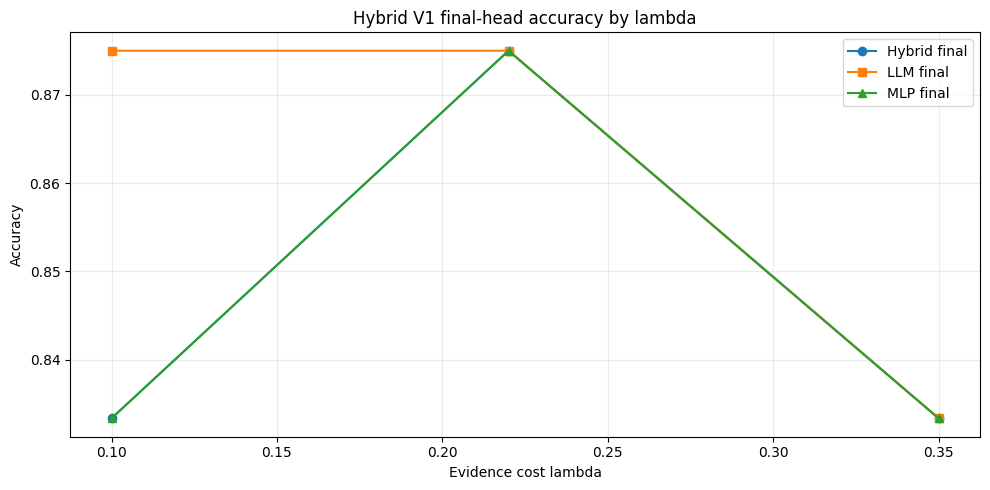

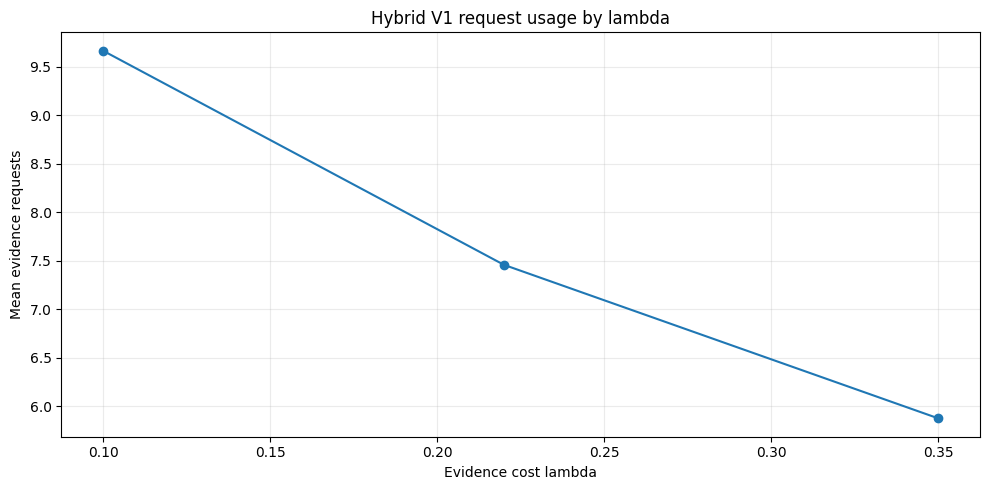

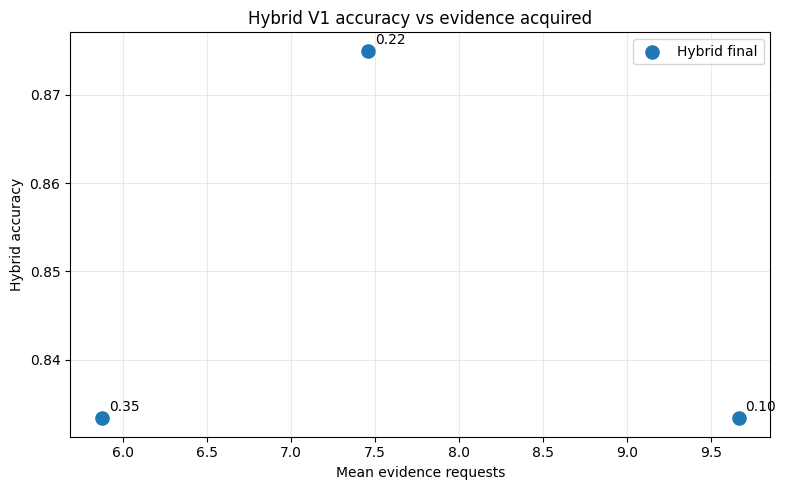

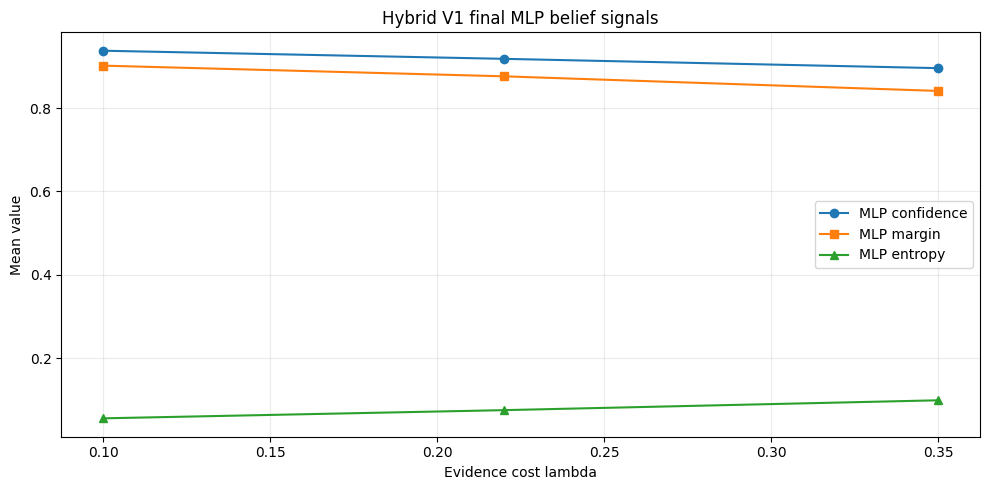

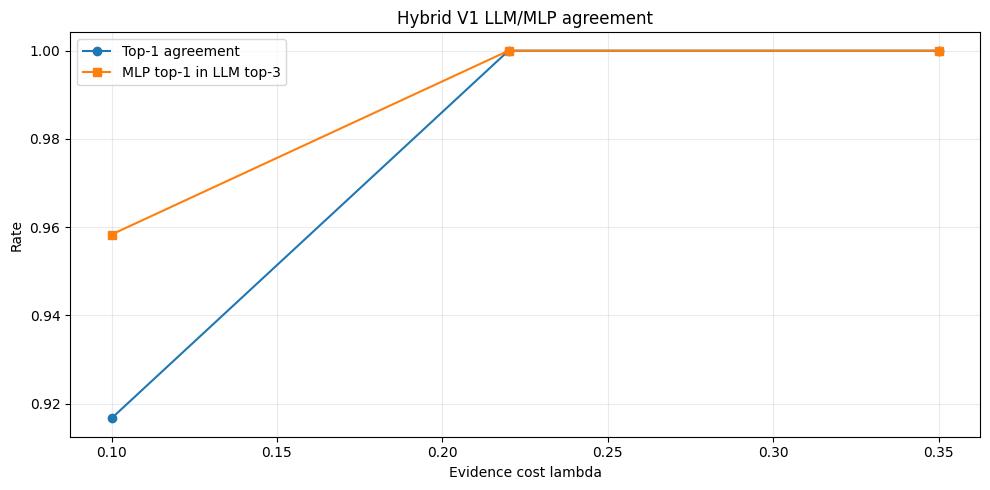

,hybrid_accuracy,hybrid_top3_accuracy,hybrid_top5_accuracy,hybrid_macro_f1,llm_final_accuracy,llm_final_top3_accuracy,llm_final_top5_accuracy,llm_final_macro_f1,mlp_final_accuracy,mlp_final_top3_accuracy,...,disagreement_triggered_continue_rate,hybrid_mlp_forced_stop_rate,turn_distribution,hybrid_final_source_distribution,stop_reason_distribution,run_name,evidence_cost_lambda,max_request_cap,num_cases,runtime_seconds
0,0.833333,1.000000,1.000000,0.756410,0.875000,0.916667,0.916667,0.813333,0.833333,1.000000,...,0.041667,0.0,"{'0': 1, '2': 1, '3': 5, '4': 3, '5': 1, '6': 2, '7': 1, '8': 1, '9': 1, '11': 1, '15': 1, '18': 1, '23': 2, '24': 3}","{'high_confidence_mlp': 2, 'llm_mlp_agreement': 22}","{'agent_stop': 21, 'max_requests_reached': 3}",hybrid_mlp_feedback_live_test_1perclass_cap24_3lambdas_hybrid_mlp_feedback_v1,0.10,24,24,870.246113
1,0.875000,0.958333,0.958333,0.813333,0.875000,0.916667,0.916667,0.813333,0.875000,0.958333,...,0.000000,0.0,"{'1': 1, '2': 4, '3': 4, '4': 2, '5': 3, '6': 2, '7': 2, '8': 1, '12': 1, '19': 1, '22': 1, '24': 2}",{'llm_mlp_agreement': 24},"{'agent_stop': 22, 'max_requests_reached': 2}",hybrid_mlp_feedback_live_test_1perclass_cap24_3lambdas_hybrid_mlp_feedback_v1,0.22,24,24,659.582926
2,0.833333,0.916667,0.916667,0.743590,0.833333,0.875000,0.875000,0.743590,0.833333,0.916667,...,0.000000,0.0,"{'1': 5, '2': 2, '3': 4, '4': 2, '5': 3, '6': 1, '7': 2, '9': 2, '17': 1, '18': 1, '24': 1}",{'llm_mlp_agreement': 24},"{'agent_stop': 23, 'max_requests_reached': 1}",hybrid_mlp_feedback_live_test_1perclass_cap24_3lambdas_hybrid_mlp_feedback_v1,0.35,24,24,521.978667


In [22]:
# Hybrid V1 visual analysis.

if summary_frame.empty:
    print("No summary frame was generated. Enable dry-run or live execution to create plots.")
else:
    plt.figure(figsize=(10, 5))
    plt.plot(summary_frame["evidence_cost_lambda"], summary_frame["hybrid_accuracy"], marker="o", label="Hybrid final")
    plt.plot(summary_frame["evidence_cost_lambda"], summary_frame["llm_final_accuracy"], marker="s", label="LLM final")
    plt.plot(summary_frame["evidence_cost_lambda"], summary_frame["mlp_final_accuracy"], marker="^", label="MLP final")
    plt.xlabel("Evidence cost lambda")
    plt.ylabel("Accuracy")
    plt.title("Hybrid V1 final-head accuracy by lambda")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "final_head_accuracy_by_lambda.png", dpi=180)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(summary_frame["evidence_cost_lambda"], summary_frame["mean_requests"], marker="o")
    plt.xlabel("Evidence cost lambda")
    plt.ylabel("Mean evidence requests")
    plt.title("Hybrid V1 request usage by lambda")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "mean_requests_by_lambda.png", dpi=180)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.scatter(summary_frame["mean_requests"], summary_frame["hybrid_accuracy"], s=90, label="Hybrid final")
    for row in summary_frame.itertuples(index=False):
        plt.annotate(f"{row.evidence_cost_lambda:.2f}", (row.mean_requests, row.hybrid_accuracy), textcoords="offset points", xytext=(5, 5))
    plt.xlabel("Mean evidence requests")
    plt.ylabel("Hybrid accuracy")
    plt.title("Hybrid V1 accuracy vs evidence acquired")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "accuracy_vs_mean_requests.png", dpi=180)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(summary_frame["evidence_cost_lambda"], summary_frame["mean_mlp_confidence"], marker="o", label="MLP confidence")
    plt.plot(summary_frame["evidence_cost_lambda"], summary_frame["mean_mlp_margin"], marker="s", label="MLP margin")
    plt.plot(summary_frame["evidence_cost_lambda"], summary_frame["mean_mlp_entropy"], marker="^", label="MLP entropy")
    plt.xlabel("Evidence cost lambda")
    plt.ylabel("Mean value")
    plt.title("Hybrid V1 final MLP belief signals")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "mlp_belief_signals_by_lambda.png", dpi=180)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(summary_frame["evidence_cost_lambda"], summary_frame["llm_mlp_top1_agreement_rate"], marker="o", label="Top-1 agreement")
    plt.plot(summary_frame["evidence_cost_lambda"], summary_frame["mlp_in_llm_top3_rate"], marker="s", label="MLP top-1 in LLM top-3")
    plt.xlabel("Evidence cost lambda")
    plt.ylabel("Rate")
    plt.title("Hybrid V1 LLM/MLP agreement")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "llm_mlp_agreement_by_lambda.png", dpi=180)
    plt.show()

    display(summary_frame)


## Qualitative Trace Snapshots

In [23]:
# Qualitative examples from the best hybrid lambda.

if summary_frame.empty:
    print("No qualitative examples available yet.")
else:
    best_lambda = float(summary_frame.sort_values(["hybrid_accuracy", "mean_requests"], ascending=[False, True]).iloc[0]["evidence_cost_lambda"])
    best_dir = ARTIFACT_ROOT / lambda_slug(best_lambda)
    examples = []
    trace_path = best_dir / "traces.jsonl"
    if trace_path.exists():
        with trace_path.open("r", encoding="utf-8") as handle:
            for line in handle:
                row = json.loads(line)
                examples.append({
                    "case_id": row.get("case_id"),
                    "true_pathology": row.get("true_pathology"),
                    "hybrid_predicted_pathology": row.get("hybrid_predicted_pathology"),
                    "llm_predicted_pathology": row.get("llm_predicted_pathology"),
                    "mlp_predicted_pathology": row.get("mlp_predicted_pathology"),
                    "num_requests": row.get("num_requests"),
                    "stop_reason": row.get("stop_reason"),
                    "hybrid_final_source": row.get("hybrid_final_source"),
                    "final_mlp_feedback": row.get("final_mlp_feedback"),
                    "last_turn": row.get("trace", [])[-1] if row.get("trace") else None,
                })
    out_path = ARTIFACT_ROOT / "qualitative_examples_best_lambda.json"
    with out_path.open("w", encoding="utf-8") as handle:
        json.dump(examples[:8], handle, indent=2)
    print("Best lambda:", best_lambda)
    print("Saved qualitative examples to:", out_path)
    display(pd.DataFrame(examples[:8])[["case_id", "true_pathology", "hybrid_predicted_pathology", "llm_predicted_pathology", "mlp_predicted_pathology", "num_requests", "stop_reason", "hybrid_final_source"]])


Best lambda: 0.22
Saved qualitative examples to: /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_hybrid_mlp_feedback/hybrid_mlp_feedback_live_test_1perclass_cap24_3lambdas_hybrid_mlp_feedback_v1/qualitative_examples_best_lambda.json


,case_id,true_pathology,hybrid_predicted_pathology,llm_predicted_pathology,mlp_predicted_pathology,num_requests,stop_reason,hybrid_final_source
0,test:104857,Acute dystonic reactions,Acute dystonic reactions,Acute dystonic reactions,Acute dystonic reactions,1,agent_stop,llm_mlp_agreement
1,test:33118,Acute otitis media,Acute otitis media,Acute otitis media,Acute otitis media,8,agent_stop,llm_mlp_agreement
2,test:93930,Acute pulmonary edema,Acute pulmonary edema,Acute pulmonary edema,Acute pulmonary edema,5,agent_stop,llm_mlp_agreement
3,test:88250,Allergic sinusitis,Allergic sinusitis,Allergic sinusitis,Allergic sinusitis,19,agent_stop,llm_mlp_agreement
4,test:90978,Bronchiolitis,Bronchiolitis,Bronchiolitis,Bronchiolitis,3,agent_stop,llm_mlp_agreement
5,test:29123,Bronchospasm / acute asthma exacerbation,Bronchospasm / acute asthma exacerbation,Bronchospasm / acute asthma exacerbation,Bronchospasm / acute asthma exacerbation,5,agent_stop,llm_mlp_agreement
6,test:51421,Chagas,Chagas,Chagas,Chagas,24,max_requests_reached,llm_mlp_agreement
7,test:46152,Cluster headache,Cluster headache,Cluster headache,Cluster headache,6,agent_stop,llm_mlp_agreement
